In [1]:
import pandas as pd

dataset_path = "../datasets/synthetic_expense_categories.csv"

df = pd.read_csv(dataset_path)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nNumber of Unique Categories:")
print(df["Label"].nunique())

print("\nCategories:")
print(sorted(df["Label"].unique()))

print("\nClass Distribution:")
print(df["Label"].value_counts().sort_index())

print("\nSample Transactions:")
display(df.sample(10, random_state=42))

Dataset Shape: (11655, 2)

Columns:
['Transaction_Text', 'Label']

Missing Values:
Transaction_Text    0
Label               0
dtype: int64

Number of Unique Categories:
18

Categories:
['EMI', 'Education', 'Entertainment', 'Fitness', 'Food', 'Gifts_Donations', 'Groceries', 'Healthcare', 'Insurance', 'Investment', 'Miscellaneous', 'Personal_Care', 'Rent', 'Shopping', 'Subscription', 'Transport', 'Travel', 'Utilities']

Class Distribution:
Label
EMI                559
Education          624
Entertainment      713
Fitness            660
Food               663
Gifts_Donations    691
Groceries          633
Healthcare         686
Insurance          617
Investment         575
Miscellaneous      636
Personal_Care      652
Rent               557
Shopping           714
Subscription       630
Transport          670
Travel             738
Utilities          637
Name: count, dtype: int64

Sample Transactions:


,Transaction_Text,Label
3858,Payment for Google One Storage - INR 652.76 Re...,Subscription
5684,"Payment for Grofers - INR 4,637.84 Ref 754112",Groceries
9636,"Payment processed - INR 7,415.40",Fitness
9144,"IMPS to Decathlon - INR 17,942.59",Shopping
6394,"IMPS to OYO Rooms - INR 59,528.68",Travel
7814,"IMPS to Stationery Purchase - INR 1,444.77",Miscellaneous
5245,"POS purchase Two Wheeler Loan INR 20,487.04",EMI
4649,"IMPS to Flipkart - INR 7,050.11",Shopping
5816,"Jio Fiber Bill - INR 4,746.33",Utilities
6952,"Auto-debit Gift Card Purchase - INR 8,205.51",Miscellaneous


In [2]:
import re

def clean_transaction(text):
    text = str(text).lower()

    # Remove INR amounts
    text = re.sub(r'inr\s*[\d,]+(?:\.\d+)?', ' ', text)

    # Remove reference numbers
    text = re.sub(r'ref\s*\d+', ' ', text)

    # Remove standalone numbers
    text = re.sub(r'\d+(?:\.\d+)?', ' ', text)

    # Remove special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


df["Clean_Text"] = df["Transaction_Text"].apply(clean_transaction)

display(
    df[["Transaction_Text", "Clean_Text", "Label"]].sample(
        15, random_state=42
    )
)

,Transaction_Text,Clean_Text,Label
3858,Payment for Google One Storage - INR 652.76 Re...,payment for google one storage,Subscription
5684,"Payment for Grofers - INR 4,637.84 Ref 754112",payment for grofers,Groceries
9636,"Payment processed - INR 7,415.40",payment processed,Fitness
9144,"IMPS to Decathlon - INR 17,942.59",imps to decathlon,Shopping
6394,"IMPS to OYO Rooms - INR 59,528.68",imps to oyo rooms,Travel
7814,"IMPS to Stationery Purchase - INR 1,444.77",imps to stationery purchase,Miscellaneous
5245,"POS purchase Two Wheeler Loan INR 20,487.04",pos purchase two wheeler loan,EMI
4649,"IMPS to Flipkart - INR 7,050.11",imps to flipkart,Shopping
5816,"Jio Fiber Bill - INR 4,746.33",jio fiber bill,Utilities
6952,"Auto-debit Gift Card Purchase - INR 8,205.51",auto debit gift card purchase,Miscellaneous


In [4]:
print("Original:")
print(df["Transaction_Text"].iloc[10])

print("\nCleaned:")
print(df["Clean_Text"].iloc[10])

Original:
UPI/Amazon/108845

Cleaned:
upi amazon


In [5]:
print("Total rows:", len(df))
print("Unique original texts:", df["Transaction_Text"].nunique())
print("Unique cleaned texts:", df["Clean_Text"].nunique())

duplicate_count = df["Clean_Text"].duplicated().sum()

print("Duplicate cleaned texts:", duplicate_count)

Total rows: 11655
Unique original texts: 11655
Unique cleaned texts: 3067
Duplicate cleaned texts: 8588


In [6]:
label_conflicts = (
    df.groupby("Clean_Text")["Label"]
    .nunique()
)

conflicting_texts = label_conflicts[label_conflicts > 1]

print("Texts having multiple labels:", len(conflicting_texts))

if len(conflicting_texts) > 0:
    display(
        df[df["Clean_Text"].isin(conflicting_texts.index)]
        .sort_values("Clean_Text")
        .head(30)
    )

Texts having multiple labels: 429


,Transaction_Text,Label,Clean_Text
6564,Adobe Creative Cloud bill payment - Ref 128782,Subscription,adobe creative cloud bill payment
10278,Adobe Creative Cloud bill payment - Ref 510518,Insurance,adobe creative cloud bill payment
7958,Adobe Creative Cloud bill payment - Ref 653819,Subscription,adobe creative cloud bill payment
9673,Adobe Creative Cloud bill payment - Ref 941072,Subscription,adobe creative cloud bill payment
2339,Adobe Creative Cloud bill payment - Ref 335204,Subscription,adobe creative cloud bill payment
5402,adobe creative cloud bill payment - ref 471319,Subscription,adobe creative cloud bill payment
3416,Adventure Park Tickets - 2023-10-05,Entertainment,adventure park tickets
6661,Adventure Park Tickets - 2024-09-27,Entertainment,adventure park tickets
10926,Adventure Park Tickets - 2021-06-24,Entertainment,adventure park tickets
11508,Adventure Park Tickets,Entertainment,adventure park tickets


In [7]:
conflict_summary = (
    df[df["Clean_Text"].isin(conflicting_texts.index)]
    .groupby(["Clean_Text", "Label"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Clean_Text", "Count"], ascending=[True, False])
)

display(conflict_summary.head(100))

,Clean_Text,Label,Count
1,adobe creative cloud bill payment,Subscription,5
0,adobe creative cloud bill payment,Insurance,1
2,adventure park tickets,Entertainment,9
3,adventure park tickets,Fitness,1
4,adventure park tickets,Travel,1
...,...,...,...
96,auto debit taj hotels,Travel,3
95,auto debit taj hotels,Investment,1
98,auto debit urban company grooming,Personal_Care,7
97,auto debit urban company grooming,Entertainment,1


In [8]:
conflict_rows = df[df["Clean_Text"].isin(conflicting_texts.index)]

print("Conflicting unique text patterns:", len(conflicting_texts))
print("Rows involved in conflicts:", len(conflict_rows))
print("Percentage of dataset involved:",
      round(len(conflict_rows) / len(df) * 100, 2), "%")

Conflicting unique text patterns: 429
Rows involved in conflicts: 3075
Percentage of dataset involved: 26.38 %


In [9]:
conflict_pivot = (
    conflict_rows
    .groupby(["Clean_Text", "Label"])
    .size()
    .unstack(fill_value=0)
)

conflict_pivot["Total"] = conflict_pivot.sum(axis=1)

display(
    conflict_pivot
    .sort_values("Total", ascending=False)
    .head(50)
)

Label,EMI,Education,Entertainment,Fitness,Food,Gifts_Donations,Groceries,Healthcare,Insurance,Investment,Miscellaneous,Personal_Care,Rent,Shopping,Subscription,Transport,Travel,Utilities,Total
Clean_Text,,,,,,,,,,,,,,,,,,,
transaction,6,5,3,3,7,6,3,8,7,4,4,4,6,2,3,6,3,3,83
debit,8,3,3,9,3,2,10,2,4,6,3,3,3,5,7,3,4,4,82
payment processed,4,3,6,5,8,5,4,2,4,4,8,5,4,4,2,6,5,1,80
card payment,3,5,6,1,1,5,3,6,4,4,4,3,3,7,7,3,6,8,79
amazon prime video,0,0,24,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,26
decathlon,0,0,0,0,0,1,0,0,0,0,0,0,0,21,0,0,0,1,23
times prime subscription,0,0,1,0,0,0,0,0,1,0,0,0,1,0,18,1,0,0,22
mg medicines,0,0,0,0,0,0,0,18,0,0,1,1,0,0,0,0,0,0,20
diagnostic lab test,0,0,0,0,1,0,0,16,1,0,1,0,0,0,0,0,0,0,19


In [10]:
from collections import Counter

# Count how many times each label occurs for each cleaned text
label_counts = (
    df.groupby(["Clean_Text", "Label"])
      .size()
      .reset_index(name="Count")
)

# Convert each Clean_Text into a dictionary of label counts
text_label_counts = (
    label_counts
    .groupby("Clean_Text")
    .apply(
        lambda x: dict(zip(x["Label"], x["Count"])),
        include_groups=False
    )
)

print("Unique cleaned texts:", len(text_label_counts))

Unique cleaned texts: 3067


In [12]:
def resolve_label(label_dict, min_dominance=0.80, min_count=3):
    """
    Resolve conflicting labels.

    Returns:
        dominant label if confidence is strong enough
        None if the text is too ambiguous
    """

    total = sum(label_dict.values())

    # Find dominant label
    dominant_label = max(label_dict, key=label_dict.get)
    dominant_count = label_dict[dominant_label]

    dominance = dominant_count / total

    # Very small groups are not reliable
    if total < min_count:
        return None

    # Keep only strongly dominant labels
    if dominance >= min_dominance:
        return dominant_label

    return None

In [13]:
generic_texts = {
    "transaction",
    "debit",
    "payment processed",
    "card payment",
    "payment",
    "purchase",
    "debit card payment",
    "credit card payment"
}

In [14]:
clean_rows = []

for clean_text, label_dict in text_label_counts.items():

    # Remove generic transaction descriptions
    if clean_text in generic_texts:
        continue

    resolved_label = resolve_label(label_dict)

    # Skip ambiguous/conflicting patterns
    if resolved_label is None:
        continue

    clean_rows.append({
        "Clean_Text": clean_text,
        "Label": resolved_label
    })

clean_df = pd.DataFrame(clean_rows)

print("Original rows:", len(df))
print("Clean unique texts:", len(clean_df))
print("\nClass distribution:")
print(clean_df["Label"].value_counts().sort_index())

Original rows: 11655
Clean unique texts: 1530

Class distribution:
Label
EMI                81
Education          82
Entertainment      92
Fitness            86
Food               83
Gifts_Donations    79
Groceries          81
Healthcare         89
Insurance          81
Investment         84
Miscellaneous      85
Personal_Care      83
Rent               75
Shopping           95
Subscription       82
Transport          86
Travel             97
Utilities          89
Name: count, dtype: int64


In [15]:
print("Clean dataset shape:", clean_df.shape)

display(
    clean_df.sample(
        30,
        random_state=42
    )
)

Clean dataset shape: (1530, 2)


,Clean_Text,Label
654,max healthcare monthly charge,Healthcare
76,auto debit blusmart,Transport
316,decathlon sports gear payment,Fitness
1347,term insurance premium payment,Insurance
571,irctc monthly charge,Transport
918,paid to health insurance premium star,Insurance
754,online payment apollo hospital,Healthcare
1500,urban company grooming monthly charge,Personal_Care
1339,tata capital emi order,EMI
1193,pos purchase mseb electricity,Utilities


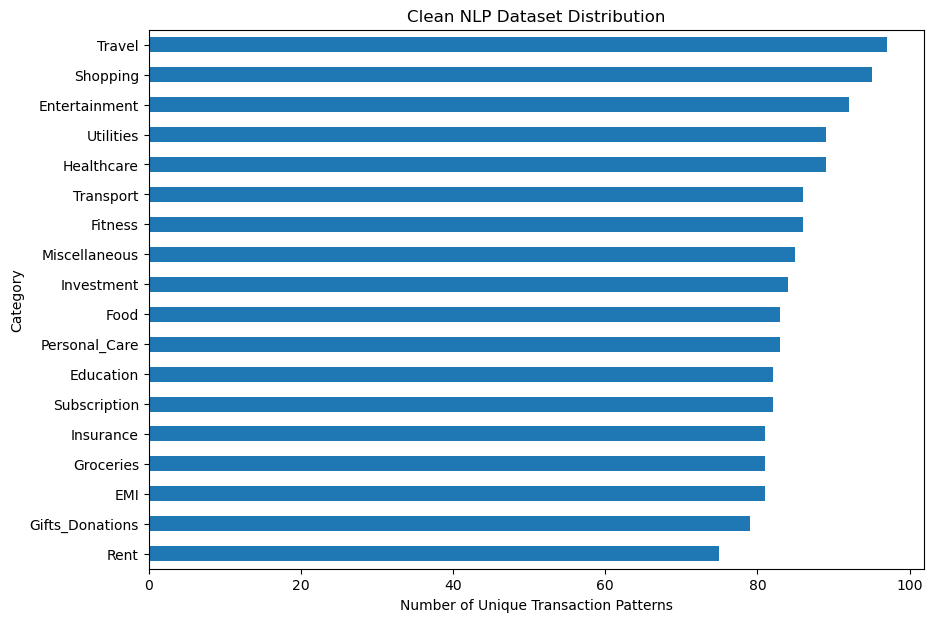

In [16]:
import matplotlib.pyplot as plt

clean_df["Label"].value_counts().sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.xlabel("Number of Unique Transaction Patterns")
plt.ylabel("Category")
plt.title("Clean NLP Dataset Distribution")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

X = clean_df["Clean_Text"]
y = clean_df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training samples: 1224
Testing samples: 306

Training class distribution:
Label
EMI                65
Education          65
Entertainment      74
Fitness            69
Food               66
Gifts_Donations    63
Groceries          65
Healthcare         71
Insurance          65
Investment         67
Miscellaneous      68
Personal_Care      66
Rent               60
Shopping           76
Subscription       66
Transport          69
Travel             78
Utilities          71
Name: count, dtype: int64

Testing class distribution:
Label
EMI                16
Education          17
Entertainment      18
Fitness            17
Food               17
Gifts_Donations    16
Groceries          16
Healthcare         18
Insurance          16
Investment         17
Miscellaneous      17
Personal_Care      17
Rent               15
Shopping           19
Subscription       16
Transport          17
Travel             19
Utilities          18
Name: count, dtype: int64


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1224, 1395)
Testing TF-IDF shape: (306, 1395)


In [20]:
tfidf.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8343 stored elements and shape (1224, 1395)>

In [21]:
tfidf.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1932 stored elements and shape (306, 1395)>

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

l1_model = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="saga",
    max_iter=5000,
    random_state=42
)

l1_model.fit(X_train_tfidf, y_train)

y_pred_l1 = l1_model.predict(X_test_tfidf)

accuracy_l1 = accuracy_score(y_test, y_pred_l1)
macro_f1_l1 = f1_score(y_test, y_pred_l1, average="macro")

print("L1 Logistic Regression")
print("----------------------")
print("Accuracy:", round(accuracy_l1, 4))
print("Macro F1:", round(macro_f1_l1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_l1))

L1 Logistic Regression
----------------------
Accuracy: 1.0
Macro F1: 1.0

Classification Report:
                 precision    recall  f1-score   support

            EMI       1.00      1.00      1.00        16
      Education       1.00      1.00      1.00        17
  Entertainment       1.00      1.00      1.00        18
        Fitness       1.00      1.00      1.00        17
           Food       1.00      1.00      1.00        17
Gifts_Donations       1.00      1.00      1.00        16
      Groceries       1.00      1.00      1.00        16
     Healthcare       1.00      1.00      1.00        18
      Insurance       1.00      1.00      1.00        16
     Investment       1.00      1.00      1.00        17
  Miscellaneous       1.00      1.00      1.00        17
  Personal_Care       1.00      1.00      1.00        17
           Rent       1.00      1.00      1.00        15
       Shopping       1.00      1.00      1.00        19
   Subscription       1.00      1.00      1.00

In [23]:
print("Total clean_df rows:", len(clean_df))

print("\nFull distribution:")
print(clean_df["Label"].value_counts().sort_index())

print("\nTrain distribution:")
print(y_train.value_counts().sort_index())

print("\nTest distribution:")
print(y_test.value_counts().sort_index())

Total clean_df rows: 1530

Full distribution:
Label
EMI                81
Education          82
Entertainment      92
Fitness            86
Food               83
Gifts_Donations    79
Groceries          81
Healthcare         89
Insurance          81
Investment         84
Miscellaneous      85
Personal_Care      83
Rent               75
Shopping           95
Subscription       82
Transport          86
Travel             97
Utilities          89
Name: count, dtype: int64

Train distribution:
Label
EMI                65
Education          65
Entertainment      74
Fitness            69
Food               66
Gifts_Donations    63
Groceries          65
Healthcare         71
Insurance          65
Investment         67
Miscellaneous      68
Personal_Care      66
Rent               60
Shopping           76
Subscription       66
Transport          69
Travel             78
Utilities          71
Name: count, dtype: int64

Test distribution:
Label
EMI                16
Education          17
Enterta

In [24]:
print("Utilities in clean_df:",
      (clean_df["Label"] == "Utilities").sum())

print("Utilities in y_train:",
      (y_train == "Utilities").sum())

print("Utilities in y_test:",
      (y_test == "Utilities").sum())

Utilities in clean_df: 89
Utilities in y_train: 71
Utilities in y_test: 18


In [25]:
train_texts = set(X_train)
test_texts = set(X_test)

overlap = train_texts.intersection(test_texts)

print("Train/Test text overlap:", len(overlap))

Train/Test text overlap: 0


Confusion Matrix:
[[16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 15  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 16  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 17  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 19  0]
 [ 0  0  0  0

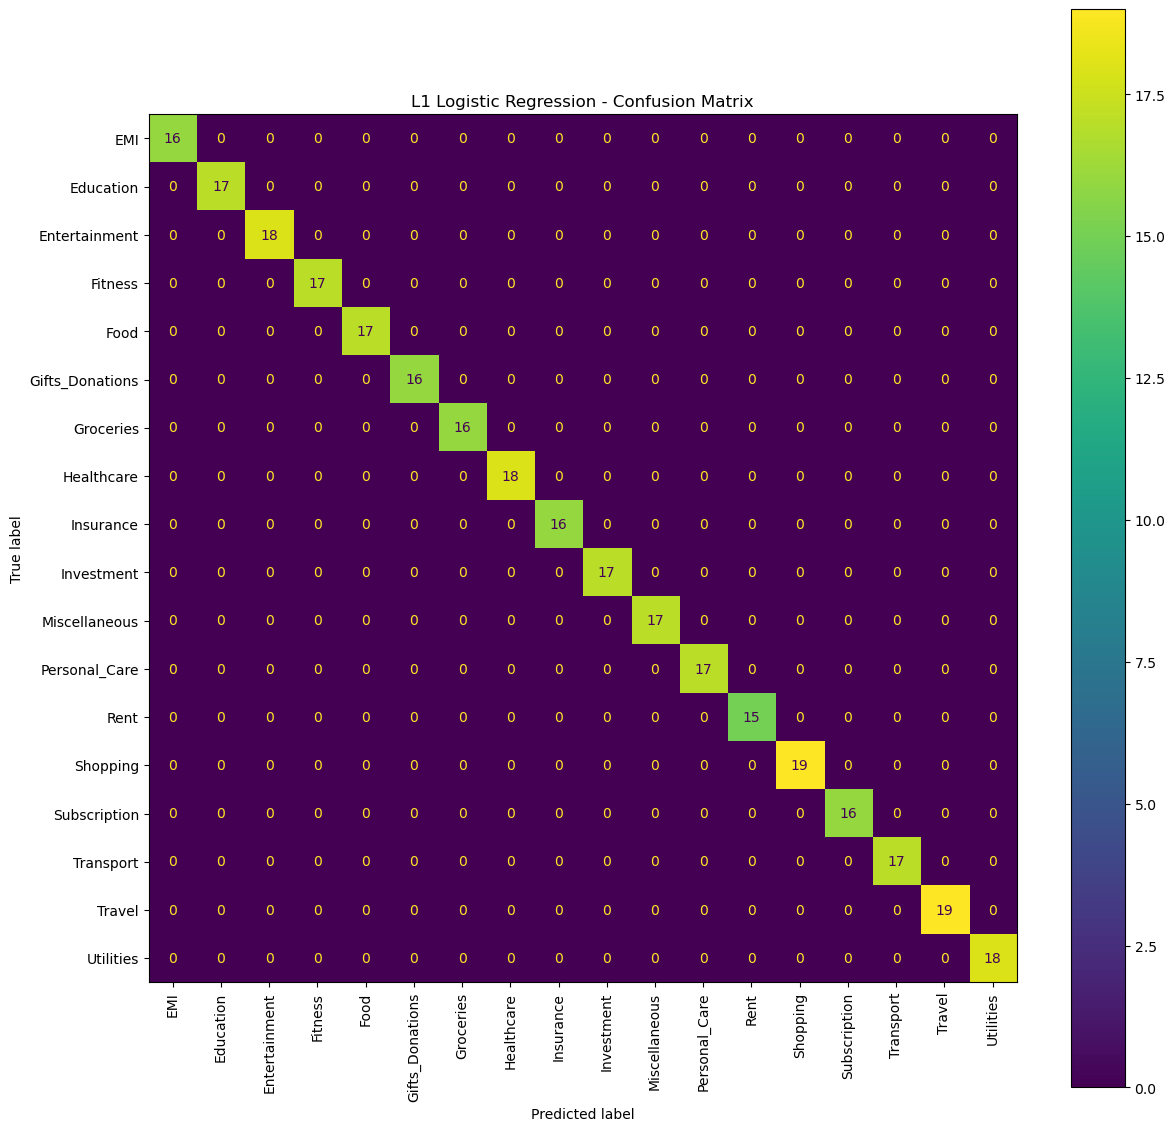

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_l1,
    labels=l1_model.classes_
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=l1_model.classes_
)

fig, ax = plt.subplots(figsize=(14, 14))
disp.plot(ax=ax, xticks_rotation=90)
plt.title("L1 Logistic Regression - Confusion Matrix")
plt.show()

In [27]:
unseen_transactions = [
    "Had dinner at a local restaurant",
    "Bought vegetables and groceries from the local market",
    "Paid for an Uber ride to office",
    "Purchased a flight ticket to Mumbai",
    "Bought clothes from a fashion store",
    "Netflix monthly subscription",
    "Paid my electricity bill",
    "Purchased medicines from a pharmacy",
    "Paid college semester fees",
    "Monthly gym membership payment",
    "Paid health insurance premium",
    "Monthly apartment rent payment",
    "Invested money in mutual funds",
    "Donated money to a temple",
    "Got a haircut at the salon",
    "Paid my car loan EMI",
    "Bought a new mobile phone",
    "Paid for home internet",
    "Bought a birthday gift for my friend",
    "Paid for a movie ticket"
]

In [28]:
unseen_clean = [
    clean_transaction(text)
    for text in unseen_transactions
]

In [29]:
unseen_tfidf = tfidf.transform(unseen_clean)

unseen_predictions = l1_model.predict(unseen_tfidf)

In [30]:
unseen_results = pd.DataFrame({
    "Transaction": unseen_transactions,
    "Clean_Text": unseen_clean,
    "Predicted_Category": unseen_predictions
})

display(unseen_results)

,Transaction,Clean_Text,Predicted_Category
0,Had dinner at a local restaurant,had dinner at a local restaurant,Food
1,Bought vegetables and groceries from the local...,bought vegetables and groceries from the local...,Food
2,Paid for an Uber ride to office,paid for an uber ride to office,Transport
3,Purchased a flight ticket to Mumbai,purchased a flight ticket to mumbai,Food
4,Bought clothes from a fashion store,bought clothes from a fashion store,Shopping
5,Netflix monthly subscription,netflix monthly subscription,Subscription
6,Paid my electricity bill,paid my electricity bill,Utilities
7,Purchased medicines from a pharmacy,purchased medicines from a pharmacy,Healthcare
8,Paid college semester fees,paid college semester fees,Education
9,Monthly gym membership payment,monthly gym membership payment,Fitness


In [31]:
unseen_probabilities = l1_model.predict_proba(unseen_tfidf)

unseen_confidence = unseen_probabilities.max(axis=1)

unseen_results["Confidence"] = (
    unseen_confidence * 100
).round(2)

display(unseen_results)

,Transaction,Clean_Text,Predicted_Category,Confidence
0,Had dinner at a local restaurant,had dinner at a local restaurant,Food,10.12
1,Bought vegetables and groceries from the local...,bought vegetables and groceries from the local...,Food,10.12
2,Paid for an Uber ride to office,paid for an uber ride to office,Transport,67.78
3,Purchased a flight ticket to Mumbai,purchased a flight ticket to mumbai,Food,10.12
4,Bought clothes from a fashion store,bought clothes from a fashion store,Shopping,66.78
5,Netflix monthly subscription,netflix monthly subscription,Subscription,77.97
6,Paid my electricity bill,paid my electricity bill,Utilities,98.63
7,Purchased medicines from a pharmacy,purchased medicines from a pharmacy,Healthcare,99.86
8,Paid college semester fees,paid college semester fees,Education,23.94
9,Monthly gym membership payment,monthly gym membership payment,Fitness,95.74


In [32]:
# Count labels for every cleaned transaction pattern

label_counts = (
    df.groupby(["Clean_Text", "Label"])
      .size()
      .reset_index(name="Count")
)

# Total number of records for each text
text_totals = (
    label_counts
    .groupby("Clean_Text")["Count"]
    .sum()
)

# Dominant label for each text
dominant_labels = (
    label_counts
    .sort_values(["Clean_Text", "Count"], ascending=[True, False])
    .drop_duplicates("Clean_Text")
    .set_index("Clean_Text")["Label"]
)

# Dominant count
dominant_counts = (
    label_counts
    .sort_values(["Clean_Text", "Count"], ascending=[True, False])
    .drop_duplicates("Clean_Text")
    .set_index("Clean_Text")["Count"]
)

# Dominance ratio
dominance_ratio = dominant_counts / text_totals

resolution_df = pd.DataFrame({
    "Dominant_Label": dominant_labels,
    "Total_Count": text_totals,
    "Dominant_Count": dominant_counts,
    "Dominance": dominance_ratio
})

resolution_df.head()

,Dominant_Label,Total_Count,Dominant_Count,Dominance
Clean_Text,,,,
adobe creatiive cloud,Subscription,1,1,1.000000
adobe creative cloud,Subscription,9,9,1.000000
adobe creative cloud bill payment,Subscription,6,5,0.833333
adobe creative cloud monthly charge,Subscription,3,3,1.000000
adobe creative cloud order,Subscription,1,1,1.000000


In [33]:
print("Total unique cleaned patterns:",
      len(resolution_df))

print("\nDominance distribution:")
print(resolution_df["Dominance"].describe())

Total unique cleaned patterns: 3067

Dominance distribution:
count    3067.000000
mean        0.967258
std         0.096856
min         0.096386
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Dominance, dtype: float64


In [34]:
valid_patterns = resolution_df[
    (resolution_df["Dominance"] >= 0.80) &
    (resolution_df["Total_Count"] >= 2)
].copy()

print("Valid patterns:",
      len(valid_patterns))

print("\nResolved label distribution:")
print(
    valid_patterns["Dominant_Label"]
    .value_counts()
    .sort_index()
)

Valid patterns: 1978

Resolved label distribution:
Dominant_Label
EMI                105
Education          115
Entertainment      116
Fitness             96
Food               136
Gifts_Donations     93
Groceries          115
Healthcare         112
Insurance           97
Investment         114
Miscellaneous      116
Personal_Care       93
Rent                83
Shopping           123
Subscription       102
Transport          123
Travel             128
Utilities          111
Name: count, dtype: int64


In [35]:
resolved_df = df.merge(
    valid_patterns[["Dominant_Label"]],
    left_on="Clean_Text",
    right_index=True,
    how="inner"
)

resolved_df = resolved_df[
    ["Transaction_Text", "Clean_Text", "Dominant_Label"]
].copy()

resolved_df.rename(
    columns={"Dominant_Label": "Label"},
    inplace=True
)

print("Resolved dataset shape:",
      resolved_df.shape)

print("\nClass distribution:")
print(
    resolved_df["Label"]
    .value_counts()
    .sort_index()
)

Resolved dataset shape: (9765, 3)

Class distribution:
Label
EMI                435
Education          529
Entertainment      616
Fitness            581
Food               488
Gifts_Donations    614
Groceries          534
Healthcare         572
Insurance          523
Investment         452
Miscellaneous      533
Personal_Care      576
Rent               491
Shopping           619
Subscription       511
Transport          530
Travel             639
Utilities          522
Name: count, dtype: int64


In [36]:
from sklearn.model_selection import GroupShuffleSplit

X = resolved_df["Clean_Text"]
y = resolved_df["Label"]
groups = resolved_df["Clean_Text"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nUnique training patterns:", X_train.nunique())
print("Unique testing patterns:", X_test.nunique())

Training samples: 7749
Testing samples: 2016

Unique training patterns: 1582
Unique testing patterns: 396


In [37]:
train_patterns = set(X_train)
test_patterns = set(X_test)

overlap = train_patterns.intersection(test_patterns)

print("Train/Test pattern overlap:", len(overlap))

Train/Test pattern overlap: 0


In [38]:
print("Training class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training class distribution:
Label
EMI                390
Education          407
Entertainment      456
Fitness            452
Food               354
Gifts_Donations    522
Groceries          411
Healthcare         487
Insurance          431
Investment         363
Miscellaneous      436
Personal_Care      448
Rent               366
Shopping           513
Subscription       411
Transport          397
Travel             508
Utilities          397
Name: count, dtype: int64

Testing class distribution:
Label
EMI                 45
Education          122
Entertainment      160
Fitness            129
Food               134
Gifts_Donations     92
Groceries          123
Healthcare          85
Insurance           92
Investment          89
Miscellaneous       97
Personal_Care      128
Rent               125
Shopping           106
Subscription       100
Transport          133
Travel             131
Utilities          125
Name: count, dtype: int64


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_word = word_tfidf.fit_transform(X_train)
X_test_word = word_tfidf.transform(X_test)

print("Word TF-IDF training shape:", X_train_word.shape)
print("Word TF-IDF testing shape:", X_test_word.shape)

Word TF-IDF training shape: (7749, 1631)
Word TF-IDF testing shape: (2016, 1631)


In [46]:
word_tfidf.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 52682 stored elements and shape (7749, 1631)>

In [48]:
word_tfidf.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12069 stored elements and shape (2016, 1631)>

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

l1_model = LogisticRegression(
    penalty="l1",
    C=1.0,
    solver="saga",
    max_iter=5000,
    random_state=42
)

l1_model.fit(X_train_word, y_train)

y_pred_l1 = l1_model.predict(X_test_word)

accuracy_l1 = accuracy_score(y_test, y_pred_l1)
macro_f1_l1 = f1_score(
    y_test,
    y_pred_l1,
    average="macro"
)

print("L1 Logistic Regression")
print("----------------------")
print("Accuracy:", round(accuracy_l1, 4))
print("Macro F1:", round(macro_f1_l1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_l1
    )
)

L1 Logistic Regression
----------------------
Accuracy: 1.0
Macro F1: 1.0

Classification Report:
                 precision    recall  f1-score   support

            EMI       1.00      1.00      1.00        45
      Education       1.00      1.00      1.00       122
  Entertainment       1.00      1.00      1.00       160
        Fitness       1.00      1.00      1.00       129
           Food       1.00      1.00      1.00       134
Gifts_Donations       1.00      1.00      1.00        92
      Groceries       1.00      1.00      1.00       123
     Healthcare       1.00      1.00      1.00        85
      Insurance       1.00      1.00      1.00        92
     Investment       1.00      1.00      1.00        89
  Miscellaneous       1.00      1.00      1.00        97
  Personal_Care       1.00      1.00      1.00       128
           Rent       1.00      1.00      1.00       125
       Shopping       1.00      1.00      1.00       106
   Subscription       1.00      1.00      1.00

In [50]:
l2_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="saga",
    max_iter=5000,
    random_state=42
)

l2_model.fit(X_train_word, y_train)

y_pred_l2 = l2_model.predict(X_test_word)

accuracy_l2 = accuracy_score(y_test, y_pred_l2)

macro_f1_l2 = f1_score(
    y_test,
    y_pred_l2,
    average="macro"
)

print("L2 Logistic Regression")
print("----------------------")
print("Accuracy:", round(accuracy_l2, 4))
print("Macro F1:", round(macro_f1_l2, 4))

L2 Logistic Regression
----------------------
Accuracy: 1.0
Macro F1: 1.0


In [51]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_word, y_train)

y_pred_svm = svm_model.predict(X_test_word)

accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

macro_f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="macro"
)

print("Linear SVM")
print("----------")
print("Accuracy:", round(accuracy_svm, 4))
print("Macro F1:", round(macro_f1_svm, 4))

Linear SVM
----------
Accuracy: 1.0
Macro F1: 1.0


In [52]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train_word,
    y_train
)

y_pred_nb = nb_model.predict(
    X_test_word
)

accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

macro_f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="macro"
)

print("Multinomial Naive Bayes")
print("-----------------------")
print("Accuracy:", round(accuracy_nb, 4))
print("Macro F1:", round(macro_f1_nb, 4))

Multinomial Naive Bayes
-----------------------
Accuracy: 0.9975
Macro F1: 0.9976


In [53]:
model_results = pd.DataFrame({
    "Model": [
        "L1 Logistic Regression",
        "L2 Logistic Regression",
        "Linear SVM",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        accuracy_l1,
        accuracy_l2,
        accuracy_svm,
        accuracy_nb
    ],
    "Macro_F1": [
        macro_f1_l1,
        macro_f1_l2,
        macro_f1_svm,
        macro_f1_nb
    ]
})

model_results = model_results.sort_values(
    "Macro_F1",
    ascending=False
).reset_index(drop=True)

display(model_results)

,Model,Accuracy,Macro_F1
0,L1 Logistic Regression,1.00000,1.000000
1,L2 Logistic Regression,1.00000,1.000000
2,Linear SVM,1.00000,1.000000
3,Multinomial Naive Bayes,0.99752,0.997602


In [54]:
unseen_predictions = pd.DataFrame({
    "Transaction": unseen_transactions,

    "L1_Logistic": l1_model.predict(
        word_tfidf.transform(unseen_clean)
    ),

    "L2_Logistic": l2_model.predict(
        word_tfidf.transform(unseen_clean)
    ),

    "Linear_SVM": svm_model.predict(
        word_tfidf.transform(unseen_clean)
    ),

    "Naive_Bayes": nb_model.predict(
        word_tfidf.transform(unseen_clean)
    )
})

display(unseen_predictions)

,Transaction,L1_Logistic,L2_Logistic,Linear_SVM,Naive_Bayes
0,Had dinner at a local restaurant,Food,Food,Food,Food
1,Bought vegetables and groceries from the local...,Food,Food,Healthcare,Food
2,Paid for an Uber ride to office,Transport,Transport,Transport,Transport
3,Purchased a flight ticket to Mumbai,Food,Shopping,Shopping,Shopping
4,Bought clothes from a fashion store,Shopping,Shopping,Shopping,Shopping
5,Netflix monthly subscription,Subscription,Entertainment,Entertainment,Entertainment
6,Paid my electricity bill,Utilities,Utilities,Utilities,Utilities
7,Purchased medicines from a pharmacy,Healthcare,Healthcare,Healthcare,Healthcare
8,Paid college semester fees,Education,Education,Education,Education
9,Monthly gym membership payment,Fitness,Fitness,Fitness,Fitness


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_char = char_tfidf.fit_transform(X_train)
X_test_char = char_tfidf.transform(X_test)

print("Training shape:", X_train_char.shape)
print("Testing shape:", X_test_char.shape)

Training shape: (7749, 3343)
Testing shape: (2016, 3343)


In [56]:
char_l2_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="saga",
    max_iter=5000,
    random_state=42
)

char_l2_model.fit(X_train_char, y_train)

y_pred_char = char_l2_model.predict(X_test_char)

accuracy_char = accuracy_score(y_test, y_pred_char)
macro_f1_char = f1_score(
    y_test,
    y_pred_char,
    average="macro"
)

print("Character TF-IDF + L2 Logistic Regression")
print("------------------------------------------")
print("Accuracy:", accuracy_char)
print("Macro F1:", macro_f1_char)

Character TF-IDF + L2 Logistic Regression
------------------------------------------
Accuracy: 1.0
Macro F1: 1.0


In [57]:
unseen_char = char_tfidf.transform(unseen_clean)

char_predictions = char_l2_model.predict(unseen_char)

unseen_char_results = pd.DataFrame({
    "Transaction": unseen_transactions,
    "Character_TFIDF": char_predictions
})

display(unseen_char_results)

,Transaction,Character_TFIDF
0,Had dinner at a local restaurant,Transport
1,Bought vegetables and groceries from the local...,Groceries
2,Paid for an Uber ride to office,Transport
3,Purchased a flight ticket to Mumbai,Entertainment
4,Bought clothes from a fashion store,Education
5,Netflix monthly subscription,Entertainment
6,Paid my electricity bill,Utilities
7,Purchased medicines from a pharmacy,Healthcare
8,Paid college semester fees,Education
9,Monthly gym membership payment,Fitness


In [58]:
expected_labels = [
    "Food",
    "Groceries",
    "Transport",
    "Travel",
    "Shopping",
    "Subscription",
    "Utilities",
    "Healthcare",
    "Education",
    "Fitness",
    "Insurance",
    "Rent",
    "Investment",
    "Gifts_Donations",
    "Personal_Care",
    "EMI",
    "Shopping",
    "Utilities",
    "Gifts_Donations",
    "Entertainment"
]

In [59]:
unseen_char_results["Expected"] = expected_labels

unseen_accuracy_char = (
    unseen_char_results["Character_TFIDF"]
    == unseen_char_results["Expected"]
).mean()

print("Unseen Accuracy:", unseen_accuracy_char)

Unseen Accuracy: 0.7


In [60]:
from scipy.sparse import hstack

X_train_combined = hstack([
    X_train_word,
    X_train_char
])

X_test_combined = hstack([
    X_test_word,
    X_test_char
])

print("Combined training shape:", X_train_combined.shape)
print("Combined testing shape:", X_test_combined.shape)

Combined training shape: (7749, 4974)
Combined testing shape: (2016, 4974)


In [61]:
combined_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="saga",
    max_iter=5000,
    random_state=42
)

combined_model.fit(
    X_train_combined,
    y_train
)

y_pred_combined = combined_model.predict(
    X_test_combined
)

accuracy_combined = accuracy_score(
    y_test,
    y_pred_combined
)

macro_f1_combined = f1_score(
    y_test,
    y_pred_combined,
    average="macro"
)

print("Combined Word + Character TF-IDF")
print("--------------------------------")
print("Accuracy:", accuracy_combined)
print("Macro F1:", macro_f1_combined)

Combined Word + Character TF-IDF
--------------------------------
Accuracy: 1.0
Macro F1: 1.0


In [62]:
unseen_combined = hstack([
    word_tfidf.transform(unseen_clean),
    char_tfidf.transform(unseen_clean)
])

combined_predictions = combined_model.predict(
    unseen_combined
)

unseen_combined_results = pd.DataFrame({
    "Transaction": unseen_transactions,
    "Expected": expected_labels,
    "Combined_TFIDF": combined_predictions
})

display(unseen_combined_results)

,Transaction,Expected,Combined_TFIDF
0,Had dinner at a local restaurant,Food,Food
1,Bought vegetables and groceries from the local...,Groceries,Groceries
2,Paid for an Uber ride to office,Transport,Transport
3,Purchased a flight ticket to Mumbai,Travel,Entertainment
4,Bought clothes from a fashion store,Shopping,Shopping
5,Netflix monthly subscription,Subscription,Entertainment
6,Paid my electricity bill,Utilities,Utilities
7,Purchased medicines from a pharmacy,Healthcare,Healthcare
8,Paid college semester fees,Education,Education
9,Monthly gym membership payment,Fitness,Fitness


In [63]:
unseen_accuracy_combined = (
    unseen_combined_results["Combined_TFIDF"]
    == unseen_combined_results["Expected"]
).mean()

print(
    "Combined Unseen Accuracy:",
    unseen_accuracy_combined
)

Combined Unseen Accuracy: 0.8


In [64]:
# Independent evaluation dataset
# DO NOT use these examples for model training

evaluation_data = [
    # ---------------- FOOD ----------------
    ("Ordered biryani from a restaurant", "Food"),
    ("Had lunch at a cafe", "Food"),
    ("Bought pizza for dinner", "Food"),
    ("Paid restaurant bill for dinner", "Food"),
    ("Ordered noodles from a food delivery app", "Food"),
    ("Had breakfast at a local cafe", "Food"),
    ("Purchased sandwiches for lunch", "Food"),
    ("Dinner bill at a restaurant", "Food"),
    ("Ordered coffee and snacks", "Food"),
    ("Paid for a family dinner", "Food"),
    ("Bought burgers from a fast food outlet", "Food"),

    # ---------------- GROCERIES ----------------
    ("Bought vegetables from the supermarket", "Groceries"),
    ("Purchased rice and cooking oil", "Groceries"),
    ("Bought fruits and household groceries", "Groceries"),
    ("Purchased milk and bread", "Groceries"),
    ("Bought vegetables from the local market", "Groceries"),
    ("Weekly grocery shopping", "Groceries"),
    ("Purchased flour and spices", "Groceries"),
    ("Bought eggs and dairy products", "Groceries"),
    ("Paid for monthly grocery shopping", "Groceries"),
    ("Purchased pulses and grains", "Groceries"),
    ("Bought fresh vegetables and fruits", "Groceries"),

    # ---------------- TRANSPORT ----------------
    ("Took an Uber to college", "Transport"),
    ("Paid for an auto rickshaw", "Transport"),
    ("Recharged my metro card", "Transport"),
    ("Paid for a cab ride", "Transport"),
    ("Bought a bus ticket to work", "Transport"),
    ("Paid taxi fare to the airport", "Transport"),
    ("Used Ola for a ride", "Transport"),
    ("Paid local bus fare", "Transport"),
    ("Recharged my metro pass", "Transport"),
    ("Paid for daily commuting", "Transport"),
    ("Booked an auto ride", "Transport"),

    # ---------------- TRAVEL ----------------
    ("Booked a flight to Delhi", "Travel"),
    ("Reserved a hotel for Goa trip", "Travel"),
    ("Purchased a railway ticket", "Travel"),
    ("Booked a vacation package", "Travel"),
    ("Paid for a hotel room during vacation", "Travel"),
    ("Booked a flight ticket for Mumbai", "Travel"),
    ("Reserved accommodation for a trip", "Travel"),
    ("Purchased train tickets for holiday", "Travel"),
    ("Paid for a tourist resort", "Travel"),
    ("Booked a bus ticket for an outstation trip", "Travel"),
    ("Planned a weekend trip and booked a hotel", "Travel"),

    # ---------------- SHOPPING ----------------
    ("Bought jeans from an online store", "Shopping"),
    ("Purchased shoes from a fashion shop", "Shopping"),
    ("Bought a Samsung mobile phone", "Shopping"),
    ("Purchased a new backpack", "Shopping"),
    ("Bought clothes for a wedding", "Shopping"),
    ("Purchased a wristwatch", "Shopping"),
    ("Bought a pair of sports shoes", "Shopping"),
    ("Purchased a new handbag", "Shopping"),
    ("Bought a jacket online", "Shopping"),
    ("Purchased sunglasses from a store", "Shopping"),
    ("Bought a new laptop bag", "Shopping"),

    # ---------------- SUBSCRIPTION ----------------
    ("Renewed my Netflix subscription", "Subscription"),
    ("Paid monthly Spotify subscription", "Subscription"),
    ("Renewed Amazon Prime membership", "Subscription"),
    ("Paid for cloud storage subscription", "Subscription"),
    ("Renewed YouTube Premium", "Subscription"),
    ("Paid monthly streaming membership", "Subscription"),
    ("Renewed an online software subscription", "Subscription"),
    ("Paid for Google One storage", "Subscription"),
    ("Renewed music streaming plan", "Subscription"),
    ("Paid annual membership fee for an online service", "Subscription"),
    ("Renewed my digital entertainment membership", "Subscription"),

    # ---------------- UTILITIES ----------------
    ("Paid my electricity bill", "Utilities"),
    ("Paid the water bill", "Utilities"),
    ("Paid monthly gas bill", "Utilities"),
    ("Renewed my broadband connection", "Utilities"),
    ("Paid the internet bill", "Utilities"),
    ("Paid electricity charges for my apartment", "Utilities"),
    ("Settled the household utility bill", "Utilities"),
    ("Paid monthly water charges", "Utilities"),
    ("Renewed home WiFi service", "Utilities"),
    ("Paid the gas utility bill", "Utilities"),
    ("Paid my mobile phone bill", "Utilities"),

    # ---------------- HEALTHCARE ----------------
    ("Bought medicines from a pharmacy", "Healthcare"),
    ("Paid hospital consultation charges", "Healthcare"),
    ("Purchased prescription medicines", "Healthcare"),
    ("Paid doctor consultation fee", "Healthcare"),
    ("Bought vitamins from a pharmacy", "Healthcare"),
    ("Paid for a medical checkup", "Healthcare"),
    ("Purchased cough syrup", "Healthcare"),
    ("Paid hospital treatment expenses", "Healthcare"),
    ("Bought medical supplies", "Healthcare"),
    ("Paid for a dentist appointment", "Healthcare"),
    ("Purchased medicine for fever", "Healthcare"),

    # ---------------- EDUCATION ----------------
    ("Paid college tuition fees", "Education"),
    ("Purchased textbooks for college", "Education"),
    ("Paid school fees", "Education"),
    ("Bought educational study material", "Education"),
    ("Paid semester examination fees", "Education"),
    ("Purchased an online course", "Education"),
    ("Paid university admission fees", "Education"),
    ("Bought reference books for studies", "Education"),
    ("Paid coaching class fees", "Education"),
    ("Purchased stationery for college", "Education"),
    ("Paid tuition class charges", "Education"),

    # ---------------- FITNESS ----------------
    ("Paid monthly gym membership", "Fitness"),
    ("Joined a new fitness center", "Fitness"),
    ("Paid for yoga classes", "Fitness"),
    ("Purchased a gym membership", "Fitness"),
    ("Paid for personal training", "Fitness"),
    ("Joined a swimming class", "Fitness"),
    ("Paid monthly fitness club fees", "Fitness"),
    ("Purchased a fitness training plan", "Fitness"),
    ("Paid for a workout class", "Fitness"),
    ("Renewed my gym membership", "Fitness"),
    ("Paid for sports training", "Fitness"),

    # ---------------- INSURANCE ----------------
    ("Paid health insurance premium", "Insurance"),
    ("Renewed my car insurance", "Insurance"),
    ("Paid life insurance premium", "Insurance"),
    ("Renewed health insurance policy", "Insurance"),
    ("Paid annual insurance premium", "Insurance"),
    ("Purchased a new insurance policy", "Insurance"),
    ("Paid vehicle insurance charges", "Insurance"),
    ("Renewed my life insurance plan", "Insurance"),
    ("Paid insurance renewal fee", "Insurance"),
    ("Paid family health insurance", "Insurance"),
    ("Renewed my insurance coverage", "Insurance"),

    # ---------------- RENT ----------------
    ("Paid monthly apartment rent", "Rent"),
    ("Paid house rent for September", "Rent"),
    ("Transferred monthly rental payment", "Rent"),
    ("Paid rent for my flat", "Rent"),
    ("Paid monthly house rental charges", "Rent"),
    ("Transferred apartment rent", "Rent"),
    ("Paid rent to my landlord", "Rent"),
    ("Monthly rental payment", "Rent"),
    ("Paid accommodation rent", "Rent"),
    ("Paid office room rent", "Rent"),
    ("Settled this month's house rent", "Rent"),

    # ---------------- INVESTMENT ----------------
    ("Invested money in mutual funds", "Investment"),
    ("Started a monthly SIP", "Investment"),
    ("Bought shares of a company", "Investment"),
    ("Invested in stocks", "Investment"),
    ("Added money to my investment account", "Investment"),
    ("Purchased mutual fund units", "Investment"),
    ("Invested savings in an index fund", "Investment"),
    ("Bought government bonds", "Investment"),
    ("Made a stock market investment", "Investment"),
    ("Transferred money to investment portfolio", "Investment"),
    ("Invested money for long term savings", "Investment"),

    # ---------------- GIFTS / DONATIONS ----------------
    ("Donated money to a temple", "Gifts_Donations"),
    ("Bought a birthday gift for my friend", "Gifts_Donations"),
    ("Donated to a charity organization", "Gifts_Donations"),
    ("Purchased a wedding gift", "Gifts_Donations"),
    ("Gave money as a birthday present", "Gifts_Donations"),
    ("Made a donation to an NGO", "Gifts_Donations"),
    ("Bought a gift for my sister", "Gifts_Donations"),
    ("Donated money to a religious organization", "Gifts_Donations"),
    ("Purchased a present for a friend", "Gifts_Donations"),
    ("Gave a cash gift at a wedding", "Gifts_Donations"),
    ("Donated to a local charity", "Gifts_Donations"),

    # ---------------- PERSONAL CARE ----------------
    ("Got a haircut at the salon", "Personal_Care"),
    ("Paid for a spa treatment", "Personal_Care"),
    ("Bought skincare products", "Personal_Care"),
    ("Visited a beauty salon", "Personal_Care"),
    ("Paid for a haircut", "Personal_Care"),
    ("Purchased shampoo and personal care products", "Personal_Care"),
    ("Paid for a salon service", "Personal_Care"),
    ("Bought cosmetics", "Personal_Care"),
    ("Paid for a facial treatment", "Personal_Care"),
    ("Purchased grooming products", "Personal_Care"),
    ("Paid for a barber service", "Personal_Care"),

    # ---------------- EMI ----------------
    ("Paid my car loan EMI", "EMI"),
    ("Paid monthly home loan installment", "EMI"),
    ("Paid my bike loan EMI", "EMI"),
    ("Made my monthly loan payment", "EMI"),
    ("Paid personal loan installment", "EMI"),
    ("Paid vehicle finance installment", "EMI"),
    ("Transferred money for my home loan", "EMI"),
    ("Paid monthly car finance", "EMI"),
    ("Settled my loan installment", "EMI"),
    ("Paid my education loan EMI", "EMI"),
    ("Made the monthly EMI payment", "EMI"),

    # ---------------- ENTERTAINMENT ----------------
    ("Paid for a movie ticket", "Entertainment"),
    ("Bought tickets for a concert", "Entertainment"),
    ("Paid for a gaming subscription", "Entertainment"),
    ("Purchased movie theater tickets", "Entertainment"),
    ("Went to a live music show", "Entertainment"),
    ("Bought tickets for a comedy show", "Entertainment"),
    ("Paid for an amusement park visit", "Entertainment"),
    ("Purchased tickets for a theater performance", "Entertainment"),
    ("Paid for a gaming event", "Entertainment"),
    ("Bought tickets for a music festival", "Entertainment"),
    ("Paid for a recreational event", "Entertainment"),

    # ---------------- MISCELLANEOUS ----------------
    ("Paid for miscellaneous household items", "Miscellaneous"),
    ("Bought stationery supplies", "Miscellaneous"),
    ("Purchased general household items", "Miscellaneous"),
    ("Paid for printing services", "Miscellaneous"),
    ("Bought office supplies", "Miscellaneous"),
    ("Paid for a document service", "Miscellaneous"),
    ("Purchased a few general items", "Miscellaneous"),
    ("Paid for packaging materials", "Miscellaneous"),
    ("Bought some miscellaneous supplies", "Miscellaneous"),
    ("Paid for photocopying services", "Miscellaneous"),
    ("Purchased general purpose supplies", "Miscellaneous"),
]

In [65]:
evaluation_df = pd.DataFrame(
    evaluation_data,
    columns=["Transaction_Text", "Expected_Label"]
)

print("Evaluation samples:", len(evaluation_df))
display(evaluation_df.head())

Evaluation samples: 198


,Transaction_Text,Expected_Label
0,Ordered biryani from a restaurant,Food
1,Had lunch at a cafe,Food
2,Bought pizza for dinner,Food
3,Paid restaurant bill for dinner,Food
4,Ordered noodles from a food delivery app,Food


In [66]:
display(
    evaluation_df["Expected_Label"]
    .value_counts()
    .sort_index()
)

Expected_Label
EMI                11
Education          11
Entertainment      11
Fitness            11
Food               11
Gifts_Donations    11
Groceries          11
Healthcare         11
Insurance          11
Investment         11
Miscellaneous      11
Personal_Care      11
Rent               11
Shopping           11
Subscription       11
Transport          11
Travel             11
Utilities          11
Name: count, dtype: int64

In [67]:
evaluation_df["Clean_Text"] = evaluation_df[
    "Transaction_Text"
].apply(clean_transaction)

display(evaluation_df.head(10))

,Transaction_Text,Expected_Label,Clean_Text
0,Ordered biryani from a restaurant,Food,ordered biryani from a restaurant
1,Had lunch at a cafe,Food,had lunch at a cafe
2,Bought pizza for dinner,Food,bought pizza for dinner
3,Paid restaurant bill for dinner,Food,paid restaurant bill for dinner
4,Ordered noodles from a food delivery app,Food,ordered noodles from a food delivery app
5,Had breakfast at a local cafe,Food,had breakfast at a local cafe
6,Purchased sandwiches for lunch,Food,purchased sandwiches for lunch
7,Dinner bill at a restaurant,Food,dinner bill at a restaurant
8,Ordered coffee and snacks,Food,ordered coffee and snacks
9,Paid for a family dinner,Food,paid for a family dinner


In [68]:
evaluation_features = hstack([
    word_tfidf.transform(
        evaluation_df["Clean_Text"]
    ),
    char_tfidf.transform(
        evaluation_df["Clean_Text"]
    )
])

evaluation_predictions = combined_model.predict(
    evaluation_features
)

evaluation_df["Predicted_Label"] = evaluation_predictions

In [69]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

evaluation_accuracy = accuracy_score(
    evaluation_df["Expected_Label"],
    evaluation_df["Predicted_Label"]
)

evaluation_macro_f1 = f1_score(
    evaluation_df["Expected_Label"],
    evaluation_df["Predicted_Label"],
    average="macro"
)

print("Independent Evaluation Results")
print("--------------------------------")
print("Accuracy:", evaluation_accuracy)
print("Macro F1:", evaluation_macro_f1)

print("\nClassification Report:")
print(
    classification_report(
        evaluation_df["Expected_Label"],
        evaluation_df["Predicted_Label"]
    )
)

Independent Evaluation Results
--------------------------------
Accuracy: 0.6767676767676768
Macro F1: 0.6755120496354718

Classification Report:
                 precision    recall  f1-score   support

            EMI       0.82      0.82      0.82        11
      Education       0.80      0.73      0.76        11
  Entertainment       0.53      0.82      0.64        11
        Fitness       0.54      0.64      0.58        11
           Food       0.46      0.55      0.50        11
Gifts_Donations       0.91      0.91      0.91        11
      Groceries       0.86      0.55      0.67        11
     Healthcare       1.00      0.82      0.90        11
      Insurance       0.92      1.00      0.96        11
     Investment       0.35      0.64      0.45        11
  Miscellaneous       0.67      0.55      0.60        11
  Personal_Care       0.89      0.73      0.80        11
           Rent       0.85      1.00      0.92        11
       Shopping       0.20      0.18      0.19        1

In [70]:
errors_df = evaluation_df[
    evaluation_df["Expected_Label"]
    != evaluation_df["Predicted_Label"]
]

print("Total errors:", len(errors_df))

display(
    errors_df[
        [
            "Transaction_Text",
            "Expected_Label",
            "Predicted_Label"
        ]
    ]
)

Total errors: 64


,Transaction_Text,Expected_Label,Predicted_Label
0,Ordered biryani from a restaurant,Food,Travel
3,Paid restaurant bill for dinner,Food,Utilities
6,Purchased sandwiches for lunch,Food,Investment
7,Dinner bill at a restaurant,Food,Utilities
9,Paid for a family dinner,Food,Shopping
...,...,...,...
189,Purchased general household items,Miscellaneous,Investment
191,Bought office supplies,Miscellaneous,Food
193,Purchased a few general items,Miscellaneous,Investment
194,Paid for packaging materials,Miscellaneous,Travel


In [71]:
# Check current resolved dataset

print("Dataset shape:", resolved_df.shape)

print("\nCategory distribution:")
display(
    resolved_df["Label"]
    .value_counts()
    .sort_index()
)

print("\nUnique cleaned transaction patterns:",
      resolved_df["Clean_Text"].nunique())

print("\nTotal duplicate rows:",
      resolved_df.duplicated(subset=["Clean_Text"]).sum())

Dataset shape: (9765, 3)

Category distribution:


Label
EMI                435
Education          529
Entertainment      616
Fitness            581
Food               488
Gifts_Donations    614
Groceries          534
Healthcare         572
Insurance          523
Investment         452
Miscellaneous      533
Personal_Care      576
Rent               491
Shopping           619
Subscription       511
Transport          530
Travel             639
Utilities          522
Name: count, dtype: int64


Unique cleaned transaction patterns: 1978

Total duplicate rows: 7787


In [72]:
# Show examples from every category

for category in sorted(resolved_df["Label"].unique()):
    print("\n" + "=" * 60)
    print("CATEGORY:", category)
    print("=" * 60)

    examples = (
        resolved_df[
            resolved_df["Label"] == category
        ]["Clean_Text"]
        .drop_duplicates()
        .sample(
            min(
                10,
                resolved_df[
                    resolved_df["Label"] == category
                ]["Clean_Text"].nunique()
            ),
            random_state=42
        )
    )

    for text in examples:
        print("-", text)


CATEGORY: EMI
- credit card emi payment
- bajaj finserv emi payment
- consumer durable loan txn dated
- upi axis bank emi
- tata capital emi monthly charge
- paid to icici personal loan
- two wheeler loan order
- online payment tata capital emi
- card swipe credit card emi
- two wheeler loan monthly charge

CATEGORY: Education
- school tuition fee
- byju s subscription txn dated
- card swipe unacademy course
- pos purchase udemy course
- exam registration fee
- upi book store purchase
- payment for byju s subscription
- neft transfer to exam registration fee
- book store purchase payment
- private tuition fee order

CATEGORY: Entertainment
- upi amazon prime video
- spotify premium monthly charge
- auto debit gaming zone
- imps to adventure park tickets
- spotify premium bill payment
- pos purchase amazon prime video
- online payment gaming zone
- payment for bookmyshow movie tickets
- adventure park tickets txn dated
- paid to spotify premium

CATEGORY: Fitness
- cult fit membership 

In [75]:
augmentation_data = [

    # ================= FOOD =================
    ("Had lunch at a restaurant", "Food"),
    ("Ordered biryani for dinner", "Food"),
    ("Paid for breakfast at a cafe", "Food"),
    ("Bought pizza for dinner", "Food"),
    ("Ordered food from Swiggy", "Food"),
    ("Ordered dinner through Zomato", "Food"),
    ("Paid restaurant bill", "Food"),
    ("Had coffee and snacks", "Food"),
    ("Bought a meal from a food court", "Food"),
    ("Ordered noodles for lunch", "Food"),
    ("Paid for dinner with friends", "Food"),
    ("Bought sandwiches for breakfast", "Food"),
    ("Ordered paneer from a restaurant", "Food"),
    ("Paid for a cafe meal", "Food"),
    ("Bought takeaway food", "Food"),
    ("Had dinner at a local dhaba", "Food"),
    ("Ordered food for the family", "Food"),
    ("Paid for lunch at the office cafeteria", "Food"),
    ("Bought snacks and beverages", "Food"),
    ("Food delivery payment", "Food"),

    # ================= SHOPPING =================
    ("Bought a new shirt", "Shopping"),
    ("Purchased jeans online", "Shopping"),
    ("Bought a pair of shoes", "Shopping"),
    ("Ordered clothes from an online store", "Shopping"),
    ("Purchased a Samsung mobile phone", "Shopping"),
    ("Bought a new smartphone", "Shopping"),
    ("Purchased a laptop", "Shopping"),
    ("Bought wireless headphones", "Shopping"),
    ("Purchased a backpack", "Shopping"),
    ("Bought a wristwatch", "Shopping"),
    ("Purchased a handbag", "Shopping"),
    ("Bought sunglasses", "Shopping"),
    ("Ordered a jacket online", "Shopping"),
    ("Purchased sports shoes", "Shopping"),
    ("Bought clothes for a wedding", "Shopping"),
    ("Purchased a new tablet", "Shopping"),
    ("Bought a keyboard and mouse", "Shopping"),
    ("Purchased a television", "Shopping"),
    ("Bought a new camera", "Shopping"),
    ("Ordered household shopping items", "Shopping"),

    # ================= TRAVEL =================
    ("Booked a flight to Mumbai", "Travel"),
    ("Purchased an airline ticket", "Travel"),
    ("Booked a train ticket to Delhi", "Travel"),
    ("Reserved a hotel room for vacation", "Travel"),
    ("Booked accommodation for Goa trip", "Travel"),
    ("Paid for a holiday package", "Travel"),
    ("Reserved a resort for the weekend", "Travel"),
    ("Purchased railway tickets for a trip", "Travel"),
    ("Booked a flight for my vacation", "Travel"),
    ("Paid for hotel accommodation", "Travel"),
    ("Booked a bus ticket for an outstation trip", "Travel"),
    ("Reserved a hotel for a family holiday", "Travel"),
    ("Paid for a travel booking", "Travel"),
    ("Booked a room during my trip", "Travel"),
    ("Purchased tickets for a vacation", "Travel"),
    ("Booked a trip to Jaipur", "Travel"),
    ("Paid for accommodation during travel", "Travel"),
    ("Reserved a resort for vacation", "Travel"),
    ("Booked an Air India flight", "Travel"),
    ("Purchased an Indigo flight ticket", "Travel"),

    # ================= SUBSCRIPTION =================
    ("Renewed Netflix monthly plan", "Subscription"),
    ("Paid for Spotify Premium", "Subscription"),
    ("Renewed Amazon Prime membership", "Subscription"),
    ("Paid for YouTube Premium", "Subscription"),
    ("Renewed Google One storage", "Subscription"),
    ("Paid monthly cloud storage fee", "Subscription"),
    ("Renewed a software subscription", "Subscription"),
    ("Paid for Adobe Creative Cloud", "Subscription"),
    ("Renewed LinkedIn Premium", "Subscription"),
    ("Paid for an online news subscription", "Subscription"),
    ("Renewed a streaming service", "Subscription"),
    ("Paid monthly membership for an online service", "Subscription"),
    ("Renewed my digital membership", "Subscription"),
    ("Paid for a premium app subscription", "Subscription"),
    ("Renewed an annual online subscription", "Subscription"),
    ("Paid for cloud hosting service", "Subscription"),
    ("Renewed Microsoft subscription", "Subscription"),
    ("Paid for an online service plan", "Subscription"),
    ("Renewed music streaming plan", "Subscription"),
    ("Monthly subscription renewal", "Subscription"),

    # ================= INVESTMENT =================
    ("Invested money in mutual funds", "Investment"),
    ("Started a monthly SIP", "Investment"),
    ("Purchased shares", "Investment"),
    ("Invested in stocks", "Investment"),
    ("Bought mutual fund units", "Investment"),
    ("Invested money in an index fund", "Investment"),
    ("Added money to my investment portfolio", "Investment"),
    ("Purchased government bonds", "Investment"),
    ("Made a stock market investment", "Investment"),
    ("Transferred money to my investment account", "Investment"),
    ("Invested in an ELSS fund", "Investment"),
    ("Deposited money into PPF", "Investment"),
    ("Started investing in mutual funds", "Investment"),
    ("Bought gold bonds", "Investment"),
    ("Made a recurring deposit", "Investment"),
    ("Invested savings for the future", "Investment"),
    ("Added money to my SIP", "Investment"),
    ("Purchased an index fund", "Investment"),
    ("Made a long term investment", "Investment"),
    ("Invested through a brokerage account", "Investment"),

    # ================= FITNESS =================
    ("Paid monthly gym membership", "Fitness"),
    ("Joined a fitness center", "Fitness"),
    ("Paid for yoga classes", "Fitness"),
    ("Renewed gym membership", "Fitness"),
    ("Paid for personal training", "Fitness"),
    ("Joined a swimming class", "Fitness"),
    ("Paid for a workout program", "Fitness"),
    ("Registered for a marathon", "Fitness"),
    ("Paid for fitness classes", "Fitness"),
    ("Joined a local gym", "Fitness"),
    ("Paid for a sports training program", "Fitness"),
    ("Purchased a gym membership", "Fitness"),
    ("Paid for a yoga session", "Fitness"),
    ("Renewed my fitness club membership", "Fitness"),
    ("Joined a dance fitness class", "Fitness"),

    # ================= MISCELLANEOUS =================
    ("Paid bank service charges", "Miscellaneous"),
    ("Paid a late payment fee", "Miscellaneous"),
    ("Paid courier charges", "Miscellaneous"),
    ("Paid for photocopying", "Miscellaneous"),
    ("Bought office stationery", "Miscellaneous"),
    ("Paid for document printing", "Miscellaneous"),
    ("Paid for mobile phone repair", "Miscellaneous"),
    ("Paid parking charges", "Miscellaneous"),
    ("Purchased general office supplies", "Miscellaneous"),
    ("Paid miscellaneous service charges", "Miscellaneous"),
    ("Bought packaging materials", "Miscellaneous"),
    ("Paid for printing documents", "Miscellaneous"),
    ("Paid a service fee", "Miscellaneous"),
    ("Purchased general purpose supplies", "Miscellaneous"),
    ("Paid for a repair service", "Miscellaneous"),
]

In [81]:
augmentation_df = pd.DataFrame(
    augmentation_data,
    columns=["Transaction_Text", "Label"]
)

print("New augmentation samples:", len(augmentation_df))

New augmentation samples: 130


In [83]:
augmentation_df["Clean_Text"] = (
    augmentation_df["Transaction_Text"]
    .apply(clean_transaction)
)

display(augmentation_df.head(10))

,Transaction_Text,Label,Clean_Text
0,Had lunch at a restaurant,Food,had lunch at a restaurant
1,Ordered biryani for dinner,Food,ordered biryani for dinner
2,Paid for breakfast at a cafe,Food,paid for breakfast at a cafe
3,Bought pizza for dinner,Food,bought pizza for dinner
4,Ordered food from Swiggy,Food,ordered food from swiggy
5,Ordered dinner through Zomato,Food,ordered dinner through zomato
6,Paid restaurant bill,Food,paid restaurant bill
7,Had coffee and snacks,Food,had coffee and snacks
8,Bought a meal from a food court,Food,bought a meal from a food court
9,Ordered noodles for lunch,Food,ordered noodles for lunch


In [84]:
existing_texts = set(
    resolved_df["Clean_Text"].dropna()
)

augmentation_df["Already_Exists"] = (
    augmentation_df["Clean_Text"]
    .isin(existing_texts)
)

print(
    "Already existing:",
    augmentation_df["Already_Exists"].sum()
)

print(
    "Actually new:",
    (~augmentation_df["Already_Exists"]).sum()
)

Already existing: 0
Actually new: 130


In [85]:
print(
    "Duplicate augmentation texts:",
    augmentation_df["Clean_Text"].duplicated().sum()
)

Duplicate augmentation texts: 0


In [89]:
(~augmentation_df["Already_Exists"]).sum()

np.int64(130)

In [90]:
# Keep only the required columns
augmentation_clean = augmentation_df[
    ["Transaction_Text", "Clean_Text", "Label"]
].copy()

# Add new examples to the original resolved dataset
improved_df = pd.concat(
    [
        resolved_df[
            ["Transaction_Text", "Clean_Text", "Label"]
        ],
        augmentation_clean
    ],
    ignore_index=True
)

print("Original dataset:", resolved_df.shape)
print("Augmentation:", augmentation_clean.shape)
print("Improved dataset:", improved_df.shape)

Original dataset: (9765, 3)
Augmentation: (130, 3)
Improved dataset: (9895, 3)


In [91]:
print("Improved category distribution:")

display(
    improved_df["Label"]
    .value_counts()
    .sort_index()
)

Improved category distribution:


Label
EMI                435
Education          529
Entertainment      616
Fitness            596
Food               508
Gifts_Donations    614
Groceries          534
Healthcare         572
Insurance          523
Investment         472
Miscellaneous      548
Personal_Care      576
Rent               491
Shopping           639
Subscription       531
Transport          530
Travel             659
Utilities          522
Name: count, dtype: int64

In [92]:
print(
    "Unique cleaned texts:",
    improved_df["Clean_Text"].nunique()
)

print(
    "Duplicate cleaned texts:",
    improved_df["Clean_Text"].duplicated().sum()
)

Unique cleaned texts: 2108
Duplicate cleaned texts: 7787


In [93]:
from sklearn.model_selection import GroupShuffleSplit

X = improved_df["Clean_Text"]
y = improved_df["Label"]
groups = improved_df["Clean_Text"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train_new = X.iloc[train_idx]
X_test_new = X.iloc[test_idx]

y_train_new = y.iloc[train_idx]
y_test_new = y.iloc[test_idx]

print("Training samples:", len(X_train_new))
print("Testing samples:", len(X_test_new))

print(
    "Pattern overlap:",
    len(
        set(X_train_new)
        .intersection(set(X_test_new))
    )
)

Training samples: 7778
Testing samples: 2117
Pattern overlap: 0


In [94]:
word_tfidf_new = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_word_new = word_tfidf_new.fit_transform(
    X_train_new
)

X_test_word_new = word_tfidf_new.transform(
    X_test_new
)

print(
    "Word TF-IDF training shape:",
    X_train_word_new.shape
)

print(
    "Word TF-IDF testing shape:",
    X_test_word_new.shape
)

Word TF-IDF training shape: (7778, 1997)
Word TF-IDF testing shape: (2117, 1997)


In [95]:
char_tfidf_new = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_char_new = char_tfidf_new.fit_transform(
    X_train_new
)

X_test_char_new = char_tfidf_new.transform(
    X_test_new
)

print(
    "Character TF-IDF training shape:",
    X_train_char_new.shape
)

print(
    "Character TF-IDF testing shape:",
    X_test_char_new.shape
)

Character TF-IDF training shape: (7778, 3755)
Character TF-IDF testing shape: (2117, 3755)


In [96]:
from scipy.sparse import hstack

X_train_combined_new = hstack([
    X_train_word_new,
    X_train_char_new
])

X_test_combined_new = hstack([
    X_test_word_new,
    X_test_char_new
])

print(
    "Combined training shape:",
    X_train_combined_new.shape
)

print(
    "Combined testing shape:",
    X_test_combined_new.shape
)

Combined training shape: (7778, 5752)
Combined testing shape: (2117, 5752)


In [97]:
combined_model_new = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="saga",
    max_iter=5000,
    random_state=42
)

combined_model_new.fit(
    X_train_combined_new,
    y_train_new
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,5000
,multi_class,'deprecated'


In [98]:
y_pred_new = combined_model_new.predict(
    X_test_combined_new
)

accuracy_new = accuracy_score(
    y_test_new,
    y_pred_new
)

macro_f1_new = f1_score(
    y_test_new,
    y_pred_new,
    average="macro"
)

print("Improved Model — Group Test")
print("----------------------------")
print("Accuracy:", accuracy_new)
print("Macro F1:", macro_f1_new)

Improved Model — Group Test
----------------------------
Accuracy: 0.9981105337742088
Macro F1: 0.998216268138138


In [99]:
independent_features_new = hstack([
    word_tfidf_new.transform(
        evaluation_df["Clean_Text"]
    ),
    char_tfidf_new.transform(
        evaluation_df["Clean_Text"]
    )
])

independent_predictions_new = (
    combined_model_new.predict(
        independent_features_new
    )
)

evaluation_df["Predicted_New"] = (
    independent_predictions_new
)

In [100]:
independent_accuracy_new = accuracy_score(
    evaluation_df["Expected_Label"],
    evaluation_df["Predicted_New"]
)

independent_macro_f1_new = f1_score(
    evaluation_df["Expected_Label"],
    evaluation_df["Predicted_New"],
    average="macro"
)

print("NEW Independent Evaluation")
print("---------------------------")
print("Accuracy:", independent_accuracy_new)
print("Macro F1:", independent_macro_f1_new)

NEW Independent Evaluation
---------------------------
Accuracy: 0.7323232323232324
Macro F1: 0.7446838522036686


In [101]:
new_errors_df = evaluation_df[
    evaluation_df["Expected_Label"]
    != evaluation_df["Predicted_New"]
]

print("New errors:", len(new_errors_df))

display(
    new_errors_df[
        [
            "Transaction_Text",
            "Expected_Label",
            "Predicted_New"
        ]
    ]
)

New errors: 53


,Transaction_Text,Expected_Label,Predicted_New
12,Purchased rice and cooking oil,Groceries,Shopping
13,Bought fruits and household groceries,Groceries,Shopping
14,Purchased milk and bread,Groceries,Shopping
15,Bought vegetables from the local market,Groceries,Food
17,Purchased flour and spices,Groceries,Shopping
18,Bought eggs and dairy products,Groceries,Shopping
20,Purchased pulses and grains,Groceries,Shopping
23,Paid for an auto rickshaw,Transport,Travel
25,Paid for a cab ride,Transport,Travel
26,Bought a bus ticket to work,Transport,Shopping


In [102]:
targeted_data = [

    # =========================================================
    # GROCERIES
    # =========================================================
    ("Bought rice from the grocery store", "Groceries"),
    ("Purchased wheat flour from supermarket", "Groceries"),
    ("Bought cooking oil and spices", "Groceries"),
    ("Purchased fresh vegetables", "Groceries"),
    ("Bought fruits from the market", "Groceries"),
    ("Purchased milk and bread from supermarket", "Groceries"),
    ("Bought eggs from grocery store", "Groceries"),
    ("Purchased pulses and rice", "Groceries"),
    ("Bought household groceries", "Groceries"),
    ("Weekly grocery shopping at supermarket", "Groceries"),
    ("Purchased vegetables and fruits", "Groceries"),
    ("Bought dairy products from the supermarket", "Groceries"),
    ("Purchased food ingredients for home", "Groceries"),
    ("Bought lentils and grains", "Groceries"),
    ("Paid for groceries at the supermarket", "Groceries"),
    ("Bought potatoes and onions", "Groceries"),
    ("Purchased cereal and milk", "Groceries"),
    ("Bought spices and cooking ingredients", "Groceries"),
    ("Purchased groceries for the week", "Groceries"),
    ("Bought fresh produce from the market", "Groceries"),

    # =========================================================
    # SHOPPING
    # =========================================================
    ("Bought a new shirt from a clothing store", "Shopping"),
    ("Purchased jeans from an online store", "Shopping"),
    ("Bought new shoes", "Shopping"),
    ("Purchased a Samsung smartphone", "Shopping"),
    ("Bought a new laptop", "Shopping"),
    ("Purchased wireless headphones", "Shopping"),
    ("Bought a backpack online", "Shopping"),
    ("Purchased a wristwatch", "Shopping"),
    ("Bought a handbag from a fashion store", "Shopping"),
    ("Purchased sunglasses", "Shopping"),
    ("Bought a jacket online", "Shopping"),
    ("Purchased clothes for a wedding", "Shopping"),
    ("Bought a new tablet", "Shopping"),
    ("Purchased a television", "Shopping"),
    ("Bought a camera", "Shopping"),
    ("Purchased a keyboard and mouse", "Shopping"),
    ("Bought electronics from a retail store", "Shopping"),
    ("Purchased a new mobile phone", "Shopping"),
    ("Bought home decor items", "Shopping"),
    ("Purchased furniture for my room", "Shopping"),

    # =========================================================
    # TRANSPORT
    # =========================================================
    ("Paid Uber fare to work", "Transport"),
    ("Paid for an auto ride", "Transport"),
    ("Booked an Ola ride", "Transport"),
    ("Paid taxi fare", "Transport"),
    ("Recharged my metro card", "Transport"),
    ("Paid for a bus ride", "Transport"),
    ("Paid local transportation fare", "Transport"),
    ("Used an auto rickshaw to reach college", "Transport"),
    ("Paid for daily commuting", "Transport"),
    ("Paid cab fare to office", "Transport"),
    ("Recharged my metro pass", "Transport"),
    ("Paid toll charges", "Transport"),
    ("Recharged FASTag", "Transport"),
    ("Paid for local bus transportation", "Transport"),
    ("Booked an auto to go home", "Transport"),
    ("Paid for an Uber ride across town", "Transport"),
    ("Paid local taxi charges", "Transport"),
    ("Used Ola for daily commute", "Transport"),
    ("Paid for transportation to college", "Transport"),
    ("Paid for a short cab trip", "Transport"),

    # =========================================================
    # TRAVEL
    # =========================================================
    ("Booked a flight to Mumbai", "Travel"),
    ("Purchased an airline ticket to Delhi", "Travel"),
    ("Booked a train ticket for vacation", "Travel"),
    ("Reserved a hotel in Goa", "Travel"),
    ("Booked accommodation for a holiday", "Travel"),
    ("Purchased railway tickets for a trip", "Travel"),
    ("Booked a flight for my vacation", "Travel"),
    ("Reserved a resort for the weekend trip", "Travel"),
    ("Paid for a holiday package", "Travel"),
    ("Booked a hotel during my vacation", "Travel"),
    ("Purchased a bus ticket for an outstation trip", "Travel"),
    ("Booked a trip to Jaipur", "Travel"),
    ("Reserved accommodation while travelling", "Travel"),
    ("Purchased tickets for a family vacation", "Travel"),
    ("Booked an Air India flight", "Travel"),
    ("Purchased an Indigo flight ticket", "Travel"),
    ("Paid for hotel accommodation", "Travel"),
    ("Booked a train for my holiday", "Travel"),
    ("Reserved a resort for vacation", "Travel"),
    ("Paid for an outstation travel booking", "Travel"),

    # =========================================================
    # SUBSCRIPTION
    # =========================================================
    ("Renewed my Netflix subscription", "Subscription"),
    ("Paid for Spotify Premium subscription", "Subscription"),
    ("Renewed Amazon Prime membership", "Subscription"),
    ("Paid for YouTube Premium plan", "Subscription"),
    ("Renewed Google One storage subscription", "Subscription"),
    ("Paid monthly cloud storage subscription", "Subscription"),
    ("Renewed Adobe Creative Cloud", "Subscription"),
    ("Paid for LinkedIn Premium", "Subscription"),
    ("Renewed Microsoft subscription", "Subscription"),
    ("Paid for an online news subscription", "Subscription"),
    ("Renewed my monthly streaming plan", "Subscription"),
    ("Paid annual subscription for an online service", "Subscription"),
    ("Renewed a software service subscription", "Subscription"),
    ("Paid for premium app membership", "Subscription"),
    ("Renewed digital service membership", "Subscription"),
    ("Paid monthly cloud hosting subscription", "Subscription"),
    ("Renewed my online service plan", "Subscription"),
    ("Paid for a yearly streaming subscription", "Subscription"),
    ("Renewed an online membership", "Subscription"),
    ("Monthly subscription renewal payment", "Subscription"),

    # =========================================================
    # ENTERTAINMENT
    # =========================================================
    ("Bought a movie ticket", "Entertainment"),
    ("Purchased cinema tickets", "Entertainment"),
    ("Paid for a concert ticket", "Entertainment"),
    ("Bought tickets for a music show", "Entertainment"),
    ("Paid for a comedy show", "Entertainment"),
    ("Purchased theater tickets", "Entertainment"),
    ("Went to an amusement park", "Entertainment"),
    ("Bought tickets for a live performance", "Entertainment"),
    ("Paid for a gaming event", "Entertainment"),
    ("Purchased music festival tickets", "Entertainment"),
    ("Paid for recreational activities", "Entertainment"),
    ("Bought a ticket for a movie theater", "Entertainment"),
    ("Paid for a live music event", "Entertainment"),
    ("Purchased tickets for a comedy event", "Entertainment"),
    ("Went to a theater performance", "Entertainment"),

    # =========================================================
    # HEALTHCARE
    # =========================================================
    ("Bought medicine from a pharmacy", "Healthcare"),
    ("Purchased prescription medicine", "Healthcare"),
    ("Bought cough syrup from pharmacy", "Healthcare"),
    ("Purchased fever medicine", "Healthcare"),
    ("Paid doctor consultation fee", "Healthcare"),
    ("Paid hospital charges", "Healthcare"),
    ("Purchased medical supplies", "Healthcare"),
    ("Paid for a medical checkup", "Healthcare"),
    ("Visited a dentist and paid consultation", "Healthcare"),
    ("Bought medicines for cold", "Healthcare"),
    ("Paid for a health checkup", "Healthcare"),
    ("Purchased prescription drugs", "Healthcare"),
    ("Paid clinic consultation charges", "Healthcare"),
    ("Bought medical equipment", "Healthcare"),
    ("Paid for hospital treatment", "Healthcare"),

    # =========================================================
    # EDUCATION
    # =========================================================
    ("Paid college tuition fees", "Education"),
    ("Paid university semester fees", "Education"),
    ("Purchased a textbook for college", "Education"),
    ("Bought reference books for studies", "Education"),
    ("Paid school tuition", "Education"),
    ("Paid coaching class fees", "Education"),
    ("Purchased an online learning course", "Education"),
    ("Paid university admission fees", "Education"),
    ("Purchased educational books", "Education"),
    ("Paid examination registration fee", "Education"),
    ("Bought study material for college", "Education"),
    ("Paid tuition class charges", "Education"),
    ("Purchased books for my course", "Education"),
    ("Paid school admission charges", "Education"),
    ("Registered for an educational course", "Education"),

    # =========================================================
    # PERSONAL CARE
    # =========================================================
    ("Paid for a haircut", "Personal_Care"),
    ("Visited a beauty salon", "Personal_Care"),
    ("Paid for a facial", "Personal_Care"),
    ("Bought shampoo for personal use", "Personal_Care"),
    ("Purchased skincare products", "Personal_Care"),
    ("Paid for a barber service", "Personal_Care"),
    ("Bought cosmetics", "Personal_Care"),
    ("Paid for salon grooming", "Personal_Care"),
    ("Purchased hair care products", "Personal_Care"),
    ("Paid for a spa treatment", "Personal_Care"),
    ("Bought personal grooming products", "Personal_Care"),
    ("Paid for a beauty treatment", "Personal_Care"),
    ("Purchased skincare items", "Personal_Care"),
    ("Paid for a salon appointment", "Personal_Care"),
    ("Bought shaving and grooming products", "Personal_Care"),

    # =========================================================
    # MISCELLANEOUS
    # =========================================================
    ("Paid bank service charges", "Miscellaneous"),
    ("Paid a late payment fee", "Miscellaneous"),
    ("Paid courier charges", "Miscellaneous"),
    ("Paid for photocopying", "Miscellaneous"),
    ("Paid for document printing", "Miscellaneous"),
    ("Paid for mobile phone repair", "Miscellaneous"),
    ("Paid parking charges", "Miscellaneous"),
    ("Purchased office stationery", "Miscellaneous"),
    ("Paid miscellaneous service charges", "Miscellaneous"),
    ("Bought packaging materials", "Miscellaneous"),
    ("Paid for a repair service", "Miscellaneous"),
    ("Paid a documentation fee", "Miscellaneous"),
    ("Purchased general office supplies", "Miscellaneous"),
    ("Paid for printing documents", "Miscellaneous"),
    ("Paid a bank transaction fee", "Miscellaneous"),
]

In [103]:
targeted_df = pd.DataFrame(
    targeted_data,
    columns=["Transaction_Text", "Label"]
)

targeted_df["Clean_Text"] = (
    targeted_df["Transaction_Text"]
    .apply(clean_transaction)
)

print("Targeted samples:", len(targeted_df))

display(
    targeted_df["Label"]
    .value_counts()
    .sort_index()
)

Targeted samples: 175


Label
Education        15
Entertainment    15
Groceries        20
Healthcare       15
Miscellaneous    15
Personal_Care    15
Shopping         20
Subscription     20
Transport        20
Travel           20
Name: count, dtype: int64

In [104]:
existing_texts = set(
    improved_df["Clean_Text"].dropna()
)

targeted_df["Already_Exists"] = (
    targeted_df["Clean_Text"]
    .isin(existing_texts)
)

print(
    "Already existing:",
    targeted_df["Already_Exists"].sum()
)

print(
    "New samples:",
    (~targeted_df["Already_Exists"]).sum()
)

print(
    "Internal duplicates:",
    targeted_df["Clean_Text"].duplicated().sum()
)

Already existing: 25
New samples: 150
Internal duplicates: 0


In [105]:
# Keep only genuinely new targeted examples
targeted_new = targeted_df[
    ~targeted_df["Already_Exists"]
][
    ["Transaction_Text", "Clean_Text", "Label"]
].copy()

print("New targeted examples:", len(targeted_new))

# Add them to the current improved dataset
final_training_df = pd.concat(
    [
        improved_df[
            ["Transaction_Text", "Clean_Text", "Label"]
        ],
        targeted_new
    ],
    ignore_index=True
)

print("Final training dataset shape:", final_training_df.shape)

New targeted examples: 150
Final training dataset shape: (10045, 3)


In [106]:
display(
    final_training_df["Label"]
    .value_counts()
    .sort_index()
)

Label
EMI                435
Education          544
Entertainment      631
Fitness            596
Food               508
Gifts_Donations    614
Groceries          554
Healthcare         587
Insurance          523
Investment         472
Miscellaneous      551
Personal_Care      591
Rent               491
Shopping           658
Subscription       548
Transport          550
Travel             670
Utilities          522
Name: count, dtype: int64

In [107]:
from sklearn.model_selection import GroupShuffleSplit

X_final = final_training_df["Clean_Text"]
y_final = final_training_df["Label"]
groups_final = final_training_df["Clean_Text"]

gss_final = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_final, test_idx_final = next(
    gss_final.split(
        X_final,
        y_final,
        groups=groups_final
    )
)

X_train_final = X_final.iloc[train_idx_final]
X_test_final = X_final.iloc[test_idx_final]

y_train_final = y_final.iloc[train_idx_final]
y_test_final = y_final.iloc[test_idx_final]

print("Training samples:", len(X_train_final))
print("Testing samples:", len(X_test_final))

pattern_overlap_final = len(
    set(X_train_final).intersection(
        set(X_test_final)
    )
)

print("Pattern overlap:", pattern_overlap_final)

Training samples: 8083
Testing samples: 1962
Pattern overlap: 0


In [108]:
word_tfidf_final = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_word_final = word_tfidf_final.fit_transform(
    X_train_final
)

X_test_word_final = word_tfidf_final.transform(
    X_test_final
)

print(
    "Word TF-IDF:",
    X_train_word_final.shape,
    X_test_word_final.shape
)

Word TF-IDF: (8083, 2341) (1962, 2341)


In [109]:
char_tfidf_final = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_char_final = char_tfidf_final.fit_transform(
    X_train_final
)

X_test_char_final = char_tfidf_final.transform(
    X_test_final
)

print(
    "Character TF-IDF:",
    X_train_char_final.shape,
    X_test_char_final.shape
)

Character TF-IDF: (8083, 4213) (1962, 4213)


In [110]:
from scipy.sparse import hstack

X_train_final_combined = hstack([
    X_train_word_final,
    X_train_char_final
])

X_test_final_combined = hstack([
    X_test_word_final,
    X_test_char_final
])

print(
    "Combined training:",
    X_train_final_combined.shape
)

print(
    "Combined testing:",
    X_test_final_combined.shape
)

Combined training: (8083, 6554)
Combined testing: (1962, 6554)


In [111]:
final_candidate_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="saga",
    max_iter=5000,
    random_state=42
)

final_candidate_model.fit(
    X_train_final_combined,
    y_train_final
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,5000
,multi_class,'deprecated'


In [112]:
y_pred_final = final_candidate_model.predict(
    X_test_final_combined
)

final_group_accuracy = accuracy_score(
    y_test_final,
    y_pred_final
)

final_group_macro_f1 = f1_score(
    y_test_final,
    y_pred_final,
    average="macro"
)

print("Final Candidate — Group Test")
print("-----------------------------")
print("Accuracy:", final_group_accuracy)
print("Macro F1:", final_group_macro_f1)

Final Candidate — Group Test
-----------------------------
Accuracy: 0.9938837920489296
Macro F1: 0.994424785750145


In [113]:
independent_features_final = hstack([
    word_tfidf_final.transform(
        evaluation_df["Clean_Text"]
    ),
    char_tfidf_final.transform(
        evaluation_df["Clean_Text"]
    )
])

independent_predictions_final = (
    final_candidate_model.predict(
        independent_features_final
    )
)

evaluation_df["Predicted_Final"] = (
    independent_predictions_final
)

In [114]:
final_independent_accuracy = accuracy_score(
    evaluation_df["Expected_Label"],
    evaluation_df["Predicted_Final"]
)

final_independent_macro_f1 = f1_score(
    evaluation_df["Expected_Label"],
    evaluation_df["Predicted_Final"],
    average="macro"
)

print("FINAL CANDIDATE — Independent Evaluation")
print("----------------------------------------")
print("Accuracy:", final_independent_accuracy)
print("Macro F1:", final_independent_macro_f1)

FINAL CANDIDATE — Independent Evaluation
----------------------------------------
Accuracy: 0.8434343434343434
Macro F1: 0.8559629447310607


In [115]:
final_errors_df = evaluation_df[
    evaluation_df["Expected_Label"]
    != evaluation_df["Predicted_Final"]
]

print("Final errors:", len(final_errors_df))

display(
    final_errors_df[
        [
            "Transaction_Text",
            "Expected_Label",
            "Predicted_Final"
        ]
    ]
)

Final errors: 31


,Transaction_Text,Expected_Label,Predicted_Final
6,Purchased sandwiches for lunch,Food,Shopping
14,Purchased milk and bread,Groceries,Shopping
18,Bought eggs and dairy products,Groceries,Shopping
20,Purchased pulses and grains,Groceries,Shopping
26,Bought a bus ticket to work,Transport,Entertainment
35,Purchased a railway ticket,Travel,Shopping
56,Paid monthly Spotify subscription,Subscription,Entertainment
60,Paid monthly streaming membership,Subscription,Fitness
64,Paid annual membership fee for an online service,Subscription,Fitness
69,Renewed my broadband connection,Utilities,Subscription


In [116]:
from sklearn.metrics import classification_report

print(
    classification_report(
        evaluation_df["Expected_Label"],
        evaluation_df["Predicted_Final"],
        digits=4
    )
)

                 precision    recall  f1-score   support

            EMI     1.0000    0.8182    0.9000        11
      Education     1.0000    0.8182    0.9000        11
  Entertainment     0.8333    0.9091    0.8696        11
        Fitness     0.8462    1.0000    0.9167        11
           Food     0.7692    0.9091    0.8333        11
Gifts_Donations     1.0000    0.8182    0.9000        11
      Groceries     0.8889    0.7273    0.8000        11
     Healthcare     1.0000    0.8182    0.9000        11
      Insurance     1.0000    0.9091    0.9524        11
     Investment     1.0000    0.8182    0.9000        11
  Miscellaneous     0.7778    0.6364    0.7000        11
  Personal_Care     0.9091    0.9091    0.9091        11
           Rent     1.0000    0.9091    0.9524        11
       Shopping     0.3929    1.0000    0.5641        11
   Subscription     0.7273    0.7273    0.7273        11
      Transport     1.0000    0.9091    0.9524        11
         Travel     1.0000    

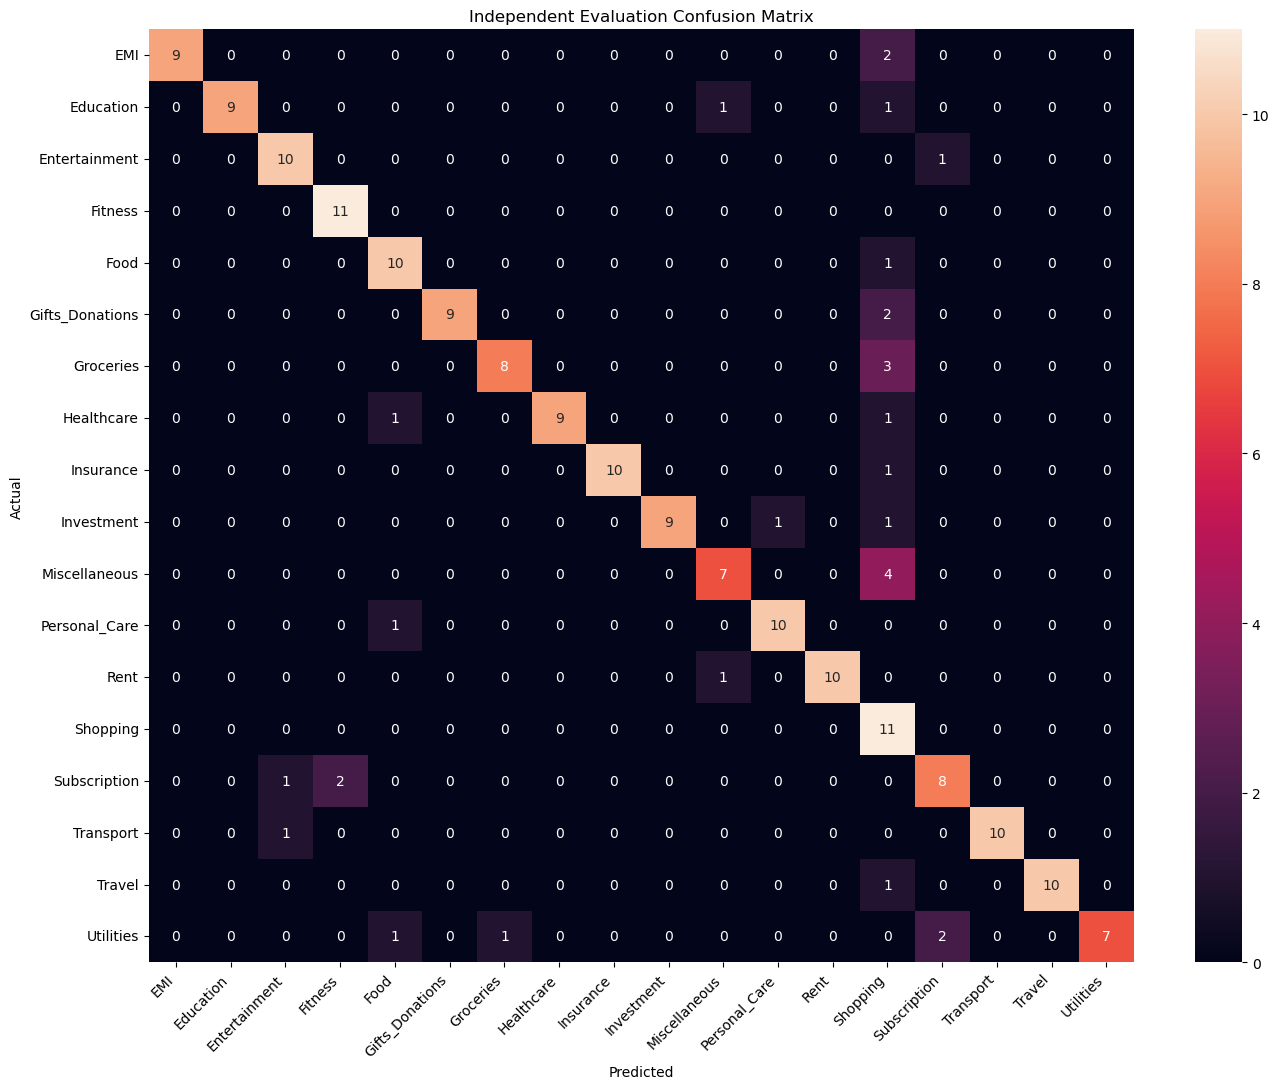

In [117]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(
    evaluation_df["Expected_Label"].unique()
)

cm = confusion_matrix(
    evaluation_df["Expected_Label"],
    evaluation_df["Predicted_Final"],
    labels=labels
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Independent Evaluation Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [118]:
final_test_transactions = [
    "Ordered masala dosa for lunch",
    "Bought tomatoes and potatoes from the market",
    "Took an auto to the railway station",
    "Booked a hotel for my Goa vacation",
    "Purchased a pair of jeans online",
    "Renewed my Spotify Premium plan",
    "Paid my electricity charges",
    "Bought tablets from the medical store",
    "Paid my college tuition",
    "Renewed my gym membership",
    "Paid my health insurance",
    "Transferred this month's apartment rent",
    "Started a SIP investment",
    "Bought a wedding present",
    "Paid for a haircut",
    "Paid my bike EMI",
    "Bought a new smartphone",
    "Purchased a movie ticket",
    "Paid my broadband bill",
    "Bought office stationery"
]

In [119]:
final_test_clean = [
    clean_transaction(text)
    for text in final_test_transactions
]

In [120]:
final_test_features = hstack([
    word_tfidf_final.transform(final_test_clean),
    char_tfidf_final.transform(final_test_clean)
])

In [121]:
final_test_predictions = (
    final_candidate_model.predict(
        final_test_features
    )
)

final_test_results = pd.DataFrame({
    "Transaction": final_test_transactions,
    "Predicted_Category": final_test_predictions
})

display(final_test_results)

,Transaction,Predicted_Category
0,Ordered masala dosa for lunch,Food
1,Bought tomatoes and potatoes from the market,Groceries
2,Took an auto to the railway station,Transport
3,Booked a hotel for my Goa vacation,Travel
4,Purchased a pair of jeans online,Shopping
5,Renewed my Spotify Premium plan,Subscription
6,Paid my electricity charges,Utilities
7,Bought tablets from the medical store,Shopping
8,Paid my college tuition,Education
9,Renewed my gym membership,Fitness


In [122]:
import pandas as pd

targeted_examples = [
    # =========================
    # HEALTHCARE
    # =========================
    ("Bought painkillers from the pharmacy", "Healthcare"),
    ("Purchased prescription medicine", "Healthcare"),
    ("Bought fever tablets from the medical store", "Healthcare"),
    ("Paid for medical medicines", "Healthcare"),
    ("Purchased cough medicine", "Healthcare"),
    ("Bought diabetes medicine", "Healthcare"),
    ("Purchased allergy tablets", "Healthcare"),
    ("Paid for a medical checkup", "Healthcare"),
    ("Bought antibiotics from the pharmacy", "Healthcare"),
    ("Purchased medicine for cold and fever", "Healthcare"),

    # =========================
    # GIFTS / DONATIONS
    # =========================
    ("Bought a birthday present for my brother", "Gifts_Donations"),
    ("Purchased a wedding gift for my cousin", "Gifts_Donations"),
    ("Bought a gift for my mother's birthday", "Gifts_Donations"),
    ("Purchased a present for my friend", "Gifts_Donations"),
    ("Bought a festival gift for my family", "Gifts_Donations"),
    ("Purchased a birthday gift", "Gifts_Donations"),
    ("Gave a donation to an NGO", "Gifts_Donations"),
    ("Donated money to a charity", "Gifts_Donations"),
    ("Bought a wedding present for my friend", "Gifts_Donations"),
    ("Sent a gift to my sister", "Gifts_Donations"),

    # =========================
    # PERSONAL CARE
    # =========================
    ("Paid for a haircut", "Personal_Care"),
    ("Visited a barber and paid for a haircut", "Personal_Care"),
    ("Paid for a salon service", "Personal_Care"),
    ("Got my hair trimmed", "Personal_Care"),
    ("Paid for a haircut and beard trim", "Personal_Care"),
    ("Paid for a spa service", "Personal_Care"),
    ("Booked a salon appointment", "Personal_Care"),
    ("Paid for a grooming service", "Personal_Care"),
    ("Got a haircut at the salon", "Personal_Care"),
    ("Paid for beard grooming", "Personal_Care"),

    # =========================
    # GROCERIES
    # =========================
    ("Bought vegetables from the supermarket", "Groceries"),
    ("Purchased rice and wheat", "Groceries"),
    ("Bought milk and bread", "Groceries"),
    ("Purchased fruits and vegetables", "Groceries"),
    ("Bought cooking oil and spices", "Groceries"),
    ("Purchased household groceries", "Groceries"),
    ("Bought potatoes and onions", "Groceries"),
    ("Purchased pulses and grains", "Groceries"),
    ("Bought eggs and dairy products", "Groceries"),
    ("Purchased fresh vegetables from the market", "Groceries"),

    # =========================
    # SHOPPING
    # =========================
    ("Bought a pair of jeans", "Shopping"),
    ("Purchased a new jacket", "Shopping"),
    ("Bought shoes online", "Shopping"),
    ("Purchased a handbag", "Shopping"),
    ("Bought a watch", "Shopping"),
    ("Purchased a pair of sunglasses", "Shopping"),
    ("Bought a new shirt", "Shopping"),
    ("Purchased a backpack", "Shopping"),
    ("Bought a new pair of shoes", "Shopping"),
    ("Purchased a winter jacket", "Shopping"),
]

targeted_df = pd.DataFrame(
    targeted_examples,
    columns=["Transaction_Text", "Label"]
)

targeted_df["Clean_Text"] = targeted_df["Transaction_Text"].apply(
    clean_transaction
)

targeted_df.head()

,Transaction_Text,Label,Clean_Text
0,Bought painkillers from the pharmacy,Healthcare,bought painkillers from the pharmacy
1,Purchased prescription medicine,Healthcare,purchased prescription medicine
2,Bought fever tablets from the medical store,Healthcare,bought fever tablets from the medical store
3,Paid for medical medicines,Healthcare,paid for medical medicines
4,Purchased cough medicine,Healthcare,purchased cough medicine


In [123]:
existing_clean = set(final_training_df["Clean_Text"])

targeted_df["Already_Exists"] = targeted_df["Clean_Text"].isin(existing_clean)

print("Total targeted examples:", len(targeted_df))
print("Already existing:", targeted_df["Already_Exists"].sum())
print("New examples:", (~targeted_df["Already_Exists"]).sum())

Total targeted examples: 50
Already existing: 8
New examples: 42


In [124]:
new_targeted_df = targeted_df[
    ~targeted_df["Already_Exists"]
].drop(columns=["Already_Exists"])

print("New targeted examples:", len(new_targeted_df))

New targeted examples: 42


In [125]:
print(
    "Internal duplicate Clean_Text:",
    new_targeted_df["Clean_Text"].duplicated().sum()
)

Internal duplicate Clean_Text: 0


In [126]:
final_training_v2 = pd.concat(
    [
        final_training_df[["Transaction_Text", "Clean_Text", "Label"]],
        new_targeted_df[["Transaction_Text", "Clean_Text", "Label"]]
    ],
    ignore_index=True
)

print("Previous training size:", len(final_training_df))
print("Final training size:", len(final_training_v2))

Previous training size: 10045
Final training size: 10087


In [127]:
print(
    final_training_v2["Label"].value_counts().sort_index()
)

Label
EMI                435
Education          544
Entertainment      631
Fitness            596
Food               508
Gifts_Donations    624
Groceries          562
Healthcare         595
Insurance          523
Investment         472
Miscellaneous      551
Personal_Care      600
Rent               491
Shopping           665
Subscription       548
Transport          550
Travel             670
Utilities          522
Name: count, dtype: int64


In [128]:
from sklearn.model_selection import GroupShuffleSplit

X = final_training_v2["Clean_Text"]
y = final_training_v2["Label"]
groups = final_training_v2["Clean_Text"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training:", len(X_train))
print("Testing :", len(X_test))

print(
    "Pattern overlap:",
    len(set(X_train) & set(X_test))
)

Training: 8084
Testing : 2003
Pattern overlap: 0


In [129]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_tfidf_v2 = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_word = word_tfidf_v2.fit_transform(X_train)
X_test_word = word_tfidf_v2.transform(X_test)

In [130]:
char_tfidf_v2 = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_char = char_tfidf_v2.fit_transform(X_train)
X_test_char = char_tfidf_v2.transform(X_test)

In [131]:
from scipy.sparse import hstack

X_train_combined = hstack([
    X_train_word,
    X_train_char
])

X_test_combined = hstack([
    X_test_word,
    X_test_char
])

print("Combined training shape:", X_train_combined.shape)
print("Combined testing shape :", X_test_combined.shape)

Combined training shape: (8084, 6870)
Combined testing shape : (2003, 6870)


In [132]:
from sklearn.linear_model import LogisticRegression

final_model_v2 = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="saga",
    max_iter=5000,
    random_state=42
)

final_model_v2.fit(
    X_train_combined,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,5000
,multi_class,'deprecated'


In [135]:
from sklearn.metrics import accuracy_score, f1_score

group_predictions = final_model_v2.predict(X_test_combined)

group_accuracy = accuracy_score(
    y_test,
    group_predictions
)

group_f1 = f1_score(
    y_test,
    group_predictions,
    average="macro"
)

print(f"Group Test Accuracy : {group_accuracy:.4f}")
print(f"Group Test Macro F1 : {group_f1:.4f}")

Group Test Accuracy : 0.9965
Group Test Macro F1 : 0.9966


In [138]:
print(evaluation_df.columns.tolist())

['Transaction_Text', 'Expected_Label', 'Clean_Text', 'Predicted_Label', 'Predicted_New', 'Predicted_Final']


In [139]:
evaluation_clean = evaluation_df["Transaction_Text"].apply(
    clean_transaction
)

evaluation_features = hstack([
    word_tfidf_v2.transform(evaluation_clean),
    char_tfidf_v2.transform(evaluation_clean)
])

evaluation_predictions_v2 = final_model_v2.predict(
    evaluation_features
)

evaluation_df["Predicted_Final_v2"] = evaluation_predictions_v2

In [140]:
print(evaluation_df.columns)
print(evaluation_df.head())

Index(['Transaction_Text', 'Expected_Label', 'Clean_Text', 'Predicted_Label',
       'Predicted_New', 'Predicted_Final', 'Predicted_Final_v2'],
      dtype='object')
                           Transaction_Text Expected_Label  \
0         Ordered biryani from a restaurant           Food   
1                       Had lunch at a cafe           Food   
2                   Bought pizza for dinner           Food   
3           Paid restaurant bill for dinner           Food   
4  Ordered noodles from a food delivery app           Food   

                                 Clean_Text Predicted_Label Predicted_New  \
0         ordered biryani from a restaurant          Travel          Food   
1                       had lunch at a cafe            Food          Food   
2                   bought pizza for dinner            Food          Food   
3           paid restaurant bill for dinner       Utilities          Food   
4  ordered noodles from a food delivery app            Food          Food   

In [142]:
from sklearn.metrics import accuracy_score, f1_score

accuracy_v2 = accuracy_score(
    evaluation_df["Expected_Label"],
    evaluation_df["Predicted_Final_v2"]
)

macro_f1_v2 = f1_score(
    evaluation_df["Expected_Label"],
    evaluation_df["Predicted_Final_v2"],
    average="macro"
)

print(f"Independent Accuracy : {accuracy_v2:.4f}")
print(f"Independent Macro F1 : {macro_f1_v2:.4f}")

Independent Accuracy : 0.8889
Independent Macro F1 : 0.8959


In [143]:
from sklearn.metrics import classification_report

print(
    classification_report(
        evaluation_df["Expected_Label"],
        evaluation_df["Predicted_Final_v2"],
        digits=4
    )
)

                 precision    recall  f1-score   support

            EMI     1.0000    0.8182    0.9000        11
      Education     1.0000    0.9091    0.9524        11
  Entertainment     0.9167    1.0000    0.9565        11
        Fitness     0.8333    0.9091    0.8696        11
           Food     1.0000    1.0000    1.0000        11
Gifts_Donations     1.0000    0.9091    0.9524        11
      Groceries     0.9167    1.0000    0.9565        11
     Healthcare     1.0000    0.8182    0.9000        11
      Insurance     1.0000    0.9091    0.9524        11
     Investment     1.0000    0.8182    0.9000        11
  Miscellaneous     0.8000    0.7273    0.7619        11
  Personal_Care     0.8462    1.0000    0.9167        11
           Rent     1.0000    0.9091    0.9524        11
       Shopping     0.4783    1.0000    0.6471        11
   Subscription     0.8000    0.7273    0.7619        11
      Transport     1.0000    0.9091    0.9524        11
         Travel     1.0000    

In [144]:
final_test_clean = [
    clean_transaction(text)
    for text in final_test_transactions
]

final_test_features = hstack([
    word_tfidf_v2.transform(final_test_clean),
    char_tfidf_v2.transform(final_test_clean)
])

final_test_predictions_v2 = final_model_v2.predict(
    final_test_features
)

final_test_results_v2 = pd.DataFrame({
    "Transaction": final_test_transactions,
    "Predicted_Category": final_test_predictions_v2
})

display(final_test_results_v2)

,Transaction,Predicted_Category
0,Ordered masala dosa for lunch,Food
1,Bought tomatoes and potatoes from the market,Groceries
2,Took an auto to the railway station,Transport
3,Booked a hotel for my Goa vacation,Travel
4,Purchased a pair of jeans online,Shopping
5,Renewed my Spotify Premium plan,Subscription
6,Paid my electricity charges,Utilities
7,Bought tablets from the medical store,Healthcare
8,Paid my college tuition,Education
9,Renewed my gym membership,Fitness


In [145]:
# ============================================
# TRAIN FINAL PRODUCTION MODEL ON ALL DATA
# ============================================

X_final = final_training_v2["Clean_Text"]
y_final = final_training_v2["Label"]

# Word TF-IDF
word_tfidf_final = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_word_final = word_tfidf_final.fit_transform(X_final)

# Character TF-IDF
char_tfidf_final = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_char_final = char_tfidf_final.fit_transform(X_final)

# Combine
X_combined_final = hstack([
    X_word_final,
    X_char_final
])

print("Final training shape:", X_combined_final.shape)

# Final Logistic Regression
expense_category_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="saga",
    max_iter=5000,
    random_state=42
)

expense_category_model.fit(
    X_combined_final,
    y_final
)

print("Final production model trained successfully.")

Final training shape: (10087, 7452)
Final production model trained successfully.


In [146]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    expense_category_model,
    "../models/expense_category_model.pkl"
)

joblib.dump(
    word_tfidf_final,
    "../models/word_tfidf.pkl"
)

joblib.dump(
    char_tfidf_final,
    "../models/char_tfidf.pkl"
)

print("All 3 model files saved successfully.")

All 3 model files saved successfully.


In [147]:
import os

for file in [
    "../models/expense_category_model.pkl",
    "../models/word_tfidf.pkl",
    "../models/char_tfidf.pkl"
]:
    print(file, "→", os.path.exists(file))

../models/expense_category_model.pkl → True
../models/word_tfidf.pkl → True
../models/char_tfidf.pkl → True
